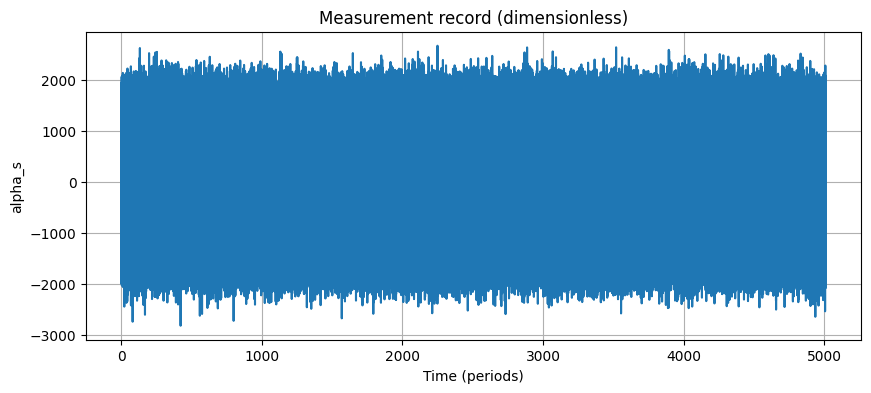

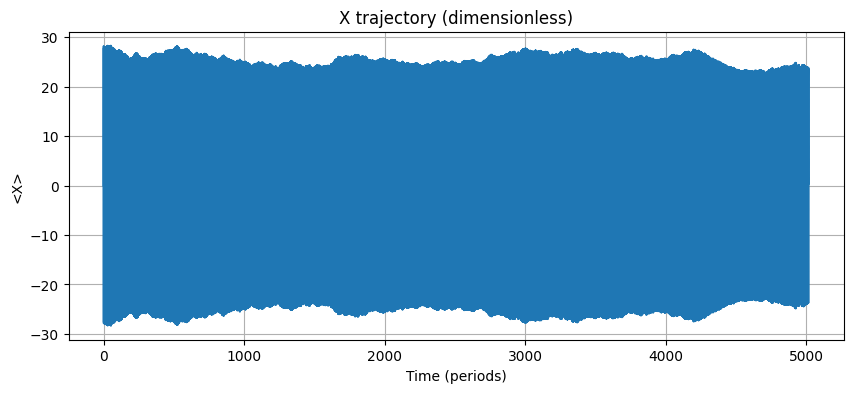

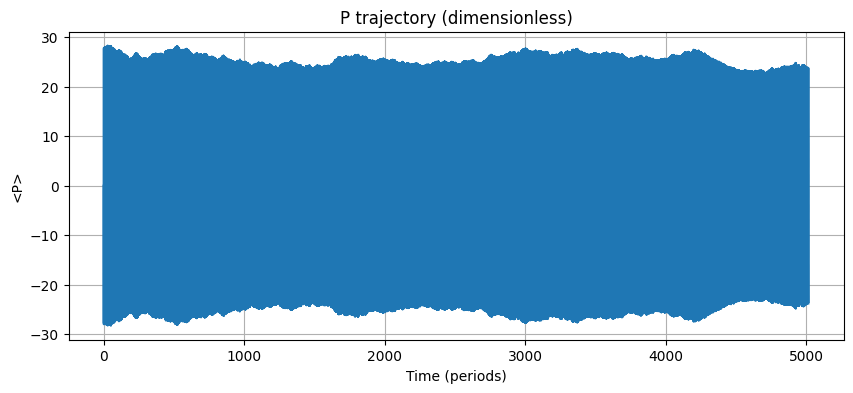

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit


hbar = 1.0
m = 1.0
omega0 = 1.0
x0 = np.sqrt(hbar / (m * omega0))
p0 = np.sqrt(hbar * m * omega0)
t0 = 1 / omega0

gamma_sc = 0.01
eta = 1.0
kappa = 1e-3

# feedback
# gamma_fb = 1/100
gamma_fb = 0

window = 50

dt_prime = 0.0005
n_steps = int(6.3e7)  


#numba accelerted loop

@njit
def run_sim(n_steps, dt_prime, gamma_fb, window, eta, kappa):

    # Initial conditions
    X = 20.0
    P = 20.0
    VX = 1.0
    VP = 1.0
    CXP = 0.0

    # Storage
    X_traj = np.zeros(n_steps)
    P_traj = np.zeros(n_steps)
    VX_traj = np.zeros(n_steps)
    VP_traj = np.zeros(n_steps)
    CXP_traj = np.zeros(n_steps)
    X2_traj = np.zeros(n_steps)
    alpha_s_history = np.zeros(n_steps)

    for i in range(n_steps - 1):

        
        dW = np.random.randn() * np.sqrt(dt_prime)

        X += P * dt_prime + np.sqrt(8 * eta * kappa) * VX * dW
        P += -X * dt_prime + np.sqrt(8 * eta * kappa) * CXP * dW
    
        VX += (2 * CXP - 8 * eta * kappa * VX**2) * dt_prime
        VP += (-2 * CXP + 2 * kappa - 8 * eta * kappa * CXP**2) * dt_prime
        CXP += (VP - VX - 8 * eta * kappa * VX * CXP) * dt_prime

        X2 = X**2 + VX

        X_traj[i+1] = X
        P_traj[i+1] = P
        VX_traj[i+1] = VX
        VP_traj[i+1] = VP
        CXP_traj[i+1] = CXP
        X2_traj [i+1] = X2


        # Measurement record
        alpha_s = X + dW / (np.sqrt(8 * eta * kappa) * dt_prime)
        alpha_s_history[i+1] = alpha_s


        if i > window:
            adot = (alpha_s_history[i] - alpha_s_history[i - window]) / (window * dt_prime)
            P -= gamma_fb * adot * dt_prime

    return X_traj, P_traj, VX_traj, VP_traj, CXP_traj, X2_traj, alpha_s_history



out = run_sim(n_steps, dt_prime, gamma_fb, window, eta, kappa)
X_traj, P_traj, VX_traj, VP_traj, CXP_traj, X2_traj, alpha_s_history = out

time = np.arange(n_steps) * dt_prime
time_periods = time / (2 * np.pi)

plt.figure(figsize=(10, 4))
plt.plot(time_periods, alpha_s_history)
plt.title("Measurement record (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("alpha_s")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_periods, X_traj)
plt.title("X trajectory (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("<X>")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_periods, P_traj)
plt.title("P trajectory (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("<P>")
plt.grid(True)
plt.show()


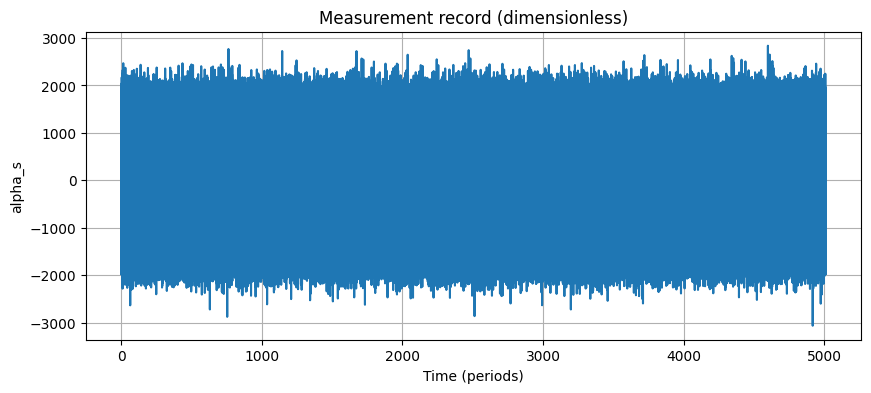

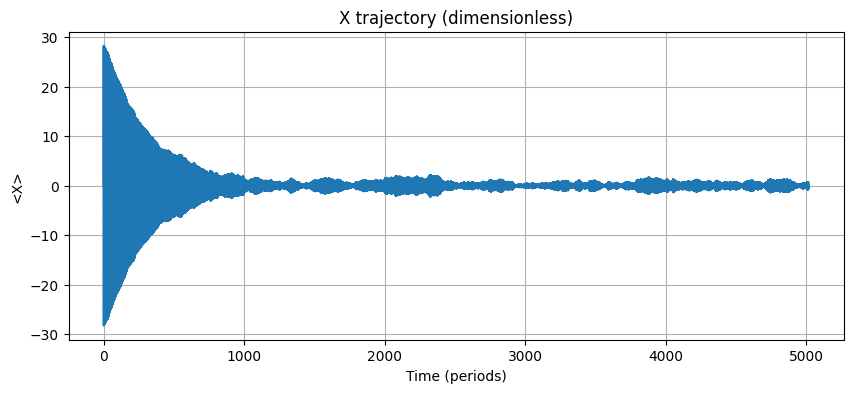

KeyboardInterrupt: 

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

#resonance requency over gamma is quality favotr tell syou how many periods
hbar = 1.0
m = 1.0
omega0 = 1.0
x0 = np.sqrt(hbar / (m * omega0))
p0 = np.sqrt(hbar * m * omega0)
t0 = 1 / omega0

gamma_sc = 0.01
eta = 1.0
kappa = 1e-3

# feedback
gamma_fb = 1/1000
window = 50

dt_prime = 0.0005
n_steps = int(6.3e7)  


#numba accelerted loop

@njit
def run_sim(n_steps, dt_prime, gamma_fb, window, eta, kappa):

    # Initial conditions
    X = 20.0
    P = 20.0
    VX = 1.0
    VP = 1.0
    CXP = 0.0

    # Storage
    X_traj = np.zeros(n_steps)
    P_traj = np.zeros(n_steps)
    VX_traj = np.zeros(n_steps)
    VP_traj = np.zeros(n_steps)
    CXP_traj = np.zeros(n_steps)
    X2_traj = np.zeros(n_steps)
    alpha_s_history = np.zeros(n_steps)

    for i in range(n_steps - 1):

        
        dW = np.random.randn() * np.sqrt(dt_prime)

        X += P * dt_prime + np.sqrt(8 * eta * kappa) * VX * dW
        P += -X * dt_prime + np.sqrt(8 * eta * kappa) * CXP * dW

        VX += (2 * CXP - 8 * eta * kappa * VX**2) * dt_prime
        VP += (-2 * CXP + 2 * kappa - 8 * eta * kappa * CXP**2) * dt_prime
        CXP += (VP - VX - 8 * eta * kappa * VX * CXP) * dt_prime

        X2 = X**2 + VX

        X_traj[i+1] = X
        P_traj[i+1] = P
        VX_traj[i+1] = VX
        VP_traj[i+1] = VP
        CXP_traj[i+1] = CXP
        X2_traj [i+1] = X2


        # Measurement record
        alpha_s = X + dW / (np.sqrt(8 * eta * kappa)* dt_prime)
        alpha_s_history[i+1] = alpha_s


        if i > window:
            adot = (alpha_s_history[i] - alpha_s_history[i - window]) / (window * dt_prime)
            P -= gamma_fb * adot * dt_prime

    return X_traj, P_traj, VX_traj, VP_traj, CXP_traj, X2_traj, alpha_s_history



out = run_sim(n_steps, dt_prime, gamma_fb, window, eta, kappa)
X_traj, P_traj, VX_traj, VP_traj, CXP_traj, X2_traj, alpha_s_history = out

time = np.arange(n_steps) * dt_prime
time_periods = time / (2 * np.pi)

plt.figure(figsize=(10, 4))
plt.plot(time_periods, alpha_s_history)
plt.title("Measurement record (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("alpha_s")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_periods, X_traj)
plt.title("X trajectory (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("<X>")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_periods, P_traj)
plt.title("P trajectory (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("<P>")
plt.grid(True)
plt.show()


/var/folders/pg/vxw1kc2j4msgjcv3j7s6ws940000gn/T/ipykernel_10151/93081719.py:72: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  var_x = simps(Pxx, f)


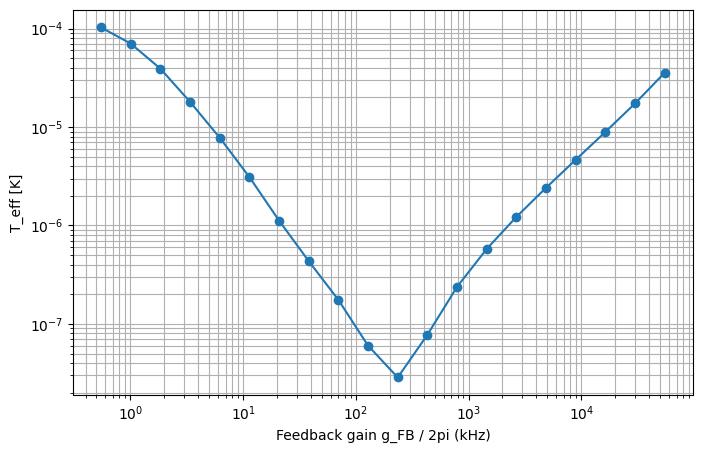

In [2]:
import numpy as np
from scipy.signal import welch 
from scipy.integrate import simps
import matplotlib.pyplot as plt
from numba import njit


eta = 1.0
kappa = 1e-3
window = 20
n_steps = int(2.5e6)
dt = 0.05
omega0 = 55e3# rad / sec x mode
hbar = 6.62607015e-34 / (2* np.pi) #m^2 kg / s
omega_z = omega0
kB = 1.380649e-23
T0 = hbar * (omega0) / kB

@njit
def simulate_trajectory(g_fb, dW_all, n_steps, dt, eta, kappa, window):
    X = 20.0
    P = 20.0
    VX = 1.0
    VP = 1.0
    CXP = 0.0

    X_traj = np.zeros(n_steps)
    alpha_hist = np.zeros(window+1)
    hist_idx = 0
    root_term = np.sqrt(8 * eta * kappa)

    for i in range(n_steps):
        dW = dW_all[i]

        # Dynamics
        X += P*dt + root_term*VX*dW
        P += -X*dt + root_term*CXP*dW
        VX += (2*CXP - 8*eta*kappa*VX**2)*dt
        VP += (-2*CXP + 2*kappa - 8*eta*kappa*CXP**2)*dt
        CXP += (VP - VX - 8*eta*kappa*VX*CXP)*dt

        X_traj[i] = X

        # Measurement
        alpha_s = X + dW / (root_term*dt)

        # Rolling buffer
        alpha_hist[hist_idx] = alpha_s
        hist_idx = (hist_idx + 1) % (window+1)

        # Feedback
        if i > window:
            prev_idx = (hist_idx - window - 1) % (window+1)
            adot = (alpha_s - alpha_hist[prev_idx]) / (window*dt)
            P -= g_fb * adot * dt

    return X_traj


# Simulate multiple feedback gains
gammas = np.logspace(-5, 0, 20)
dW_all = np.random.randn(n_steps) * np.sqrt(dt)
T_list = []
VX2_list = []
for g_fb in gammas:
    X_traj = simulate_trajectory(g_fb, dW_all, n_steps, dt, eta, kappa, window)
    VX2_list.append(np.mean(VX_traj[n_steps//2:]**2))
    
    # Compute PSD and T_eff
    fs = 1.0 / dt
    f, Pxx = welch(X_traj, fs=fs, nperseg=len(X_traj)//4)
    var_x = simps(Pxx, f)
    T_eff = var_x
    T_list.append(T_eff * T0)  # convert to mK 

#put in units for plotting
omega_m = 2*np.pi*55e3
gamma_FB = gammas * omega_m
g_pap = gamma_FB / (2*np.pi) #g paper

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,5))
plt.loglog(g_pap, T_list, 'o-')
plt.xlabel("Feedback gain g_FB / 2pi (kHz)")
plt.ylabel("T_eff [K]")
plt.grid(True, which='both')
plt.show()


In [21]:
g_pap

array([5.50000000e-04, 1.00813939e-03, 1.84790006e-03, 3.38716516e-03,
       6.20860840e-03, 1.13802594e-02, 2.08597960e-02, 3.82356038e-02,
       7.00851242e-02, 1.28464681e-01, 2.35473282e-01, 4.31617984e-01,
       7.91147439e-01, 1.45015799e+00, 2.65811163e+00, 4.87226735e+00,
       8.93077207e+00, 1.63699329e+01, 3.00057713e+01, 5.50000000e+01])

With units below

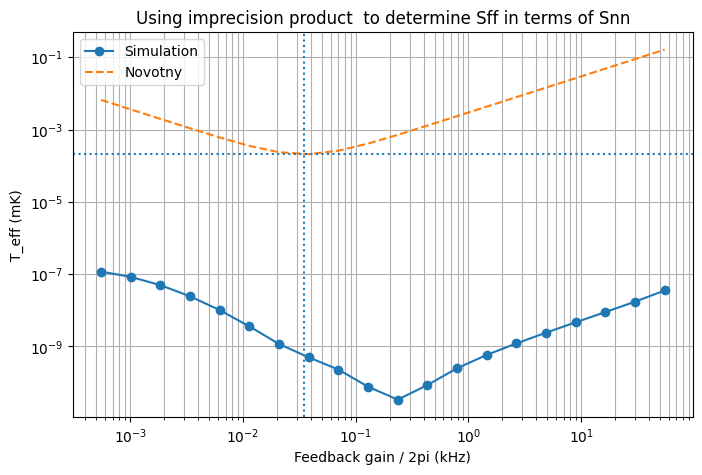

In [3]:
#from paper
# Snn = 1/(8*eta*kappa) #measurement noise (imprecision noise) alpha
#finding Snn using relation between Snn and Sff given imprecision product
# Sff = 8*eta*kappa*np.mean(VX2_list) #fluctuating force (measurement backaction,) from x
# Snn = (1/(Sff * eta))*(hbar/(4*np.pi))**2


Snn = 1 / (8 * eta * kappa)
Sff = (1 / (eta)) * (1/((4 * np.pi)**2 * Snn))
#finding Snn using relation between Snn and Sff given imprecision product did not work lol 
T_theory = []
for g_fb in gammas:
    T = np.pi*(Sff/g_fb + g_fb*Snn)*T0*1e3
    T_theory.append(T)

T_min = 2*np.pi*np.sqrt(Sff*Snn)*T0*1e3
g_opt = np.sqrt(Sff/Snn)

#converting gain of paper to units
omega_m = 2*np.pi*55e3
g_pap = gammas*omega_m/(2*np.pi)/1e3


plt.figure(figsize=(8,5))
plt.loglog(g_pap, T_list, 'o-', label='Simulation')
plt.loglog(g_pap, T_theory, '--', label='Novotny')
plt.axhline(T_min, linestyle=':')
plt.axvline(g_opt*omega_m/(2*np.pi)/1e3, linestyle=':')
plt.xlabel("Feedback gain / 2pi (kHz)")
plt.title("Using imprecision product  to determine Sff in terms of Snn")
plt.ylabel("T_eff (mK)")
plt.legend()
plt.grid(True, which='both')
plt.show()

Feb 3 8:20 am observation: novotny paper's finding Snn using relation between Snn and Sff given imprecision product doesnt work. works only if i put snn in term so th enoise term in alpha... not super sure why lol

gonna plot the different psds below for 1) simulation 2) novoty paper with impreciision product 3) novotny paper with noise term from alpha directly


before it was F = - gamma * xdot, still want same force but the way you apply the force u need measurement of position, mroe ingredinats going into it , measurement uncertainty on the position also matter, .. need posotion as welll asvelcooty 


also, when start moving beam, crazy things happen when harmoic approx breaks down. once include reaslitic bem profiles is it still a prmising way to cool. 

Trying something new Feb 9 

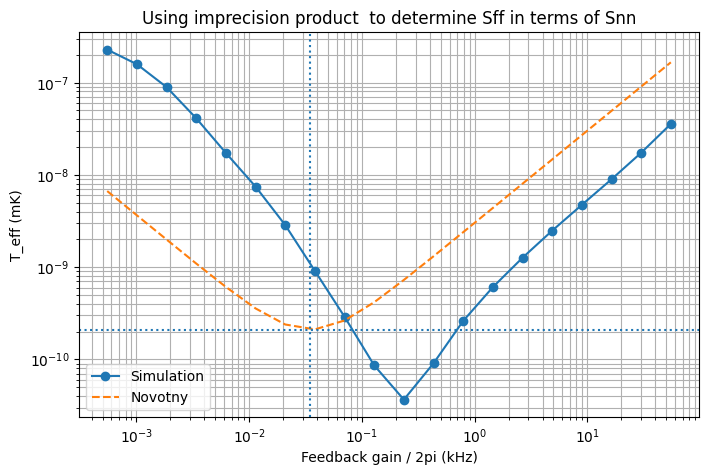

In [14]:
#from paper
# Snn = 1/(8*eta*kappa) #measurement noise (imprecision noise) alpha
#finding Snn using relation between Snn and Sff given imprecision product
# Sff = 8*eta*kappa*np.mean(VX2_list) #fluctuating force (measurement backaction,) from x
# Snn = (1/(Sff * eta))*(hbar/(4*np.pi))**2


Snn = 1 / (8 * eta * kappa) + np.mean(VX2_list) * (8 * eta * kappa +2)
Sff = (1 / (eta)) * (1/((4 * np.pi)**2 * Snn))
#finding Snn using relation between Snn and Sff given imprecision product did not work lol 
T_theory = []
for g_fb in gammas:
    T = np.pi*(Sff/g_fb + g_fb*Snn)*T0 / 1e3
    T_theory.append(T)

T_min = 2*np.pi*np.sqrt(Sff*Snn)*T0 / 1e3
g_opt = np.sqrt(Sff/Snn)

#converting gain of paper to units
omega_m = 2*np.pi*55e3
# g_pap = gammas*omega_m/(2*np.pi)/1e3
g_pap = gammas * omega_m / (2*np.pi) / 1e3




plt.figure(figsize=(8,5))
plt.loglog(g_pap, T_list, 'o-', label='Simulation')
plt.loglog(g_pap, T_theory, '--', label='Novotny')
plt.axhline(T_min, linestyle=':')
plt.axvline(g_opt*omega_m/(2*np.pi)/1e3, linestyle=':')
plt.xlabel("Feedback gain / 2pi (kHz)")
plt.title("Using imprecision product  to determine Sff in terms of Snn")
plt.ylabel("T_eff (mK)")
plt.legend()
plt.grid(True, which='both')
plt.show()

I doin't thiink above works cuz i am double counting the dW?

Maybe i can plot a sliding scale of some coeffecint let's call R to see if and where simulation and novotny would match
Snn might be proportional so 1/ 8nk but up to a factor that i've not included

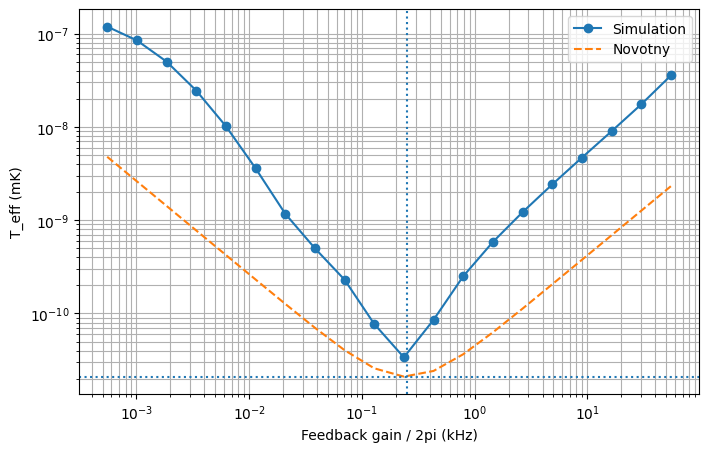

In [5]:
import numpy as np
#from paper
VX2 = np.mean(VX2_list)
# Snn = dt * VX2

# Snn = 1 / VX2
#vertical shift
A = 1e-14 #vertial shift 
C = 1400000 #proportionality constant between Snn and alpha_s nosie squared (this shifts it horizontaly only )
Snn = A*C*(1/(8*eta*kappa))#measurement noise (imprecision noise) alpha
Sff = A*(1 / (eta)) * (1/((4 * np.pi)**2 * Snn))
#finding Snn using relation between Snn and Sff given imprecision product did not work lol 
T_theory = []
for g_fb in gammas:
    T = np.pi*(Sff/g_fb + g_fb*Snn)*T0*1e3
    T_theory.append(T)

T_min = 2*np.pi*np.sqrt(Sff*Snn)*T0*1e3
g_opt = np.sqrt(Sff/Snn)

#converting gain of paper to units
omega_m = 2*np.pi*55e3
g_pap = gammas*omega_m/(2*np.pi)/1e3


plt.figure(figsize=(8,5))
plt.loglog(g_pap, T_list, 'o-', label='Simulation')
plt.loglog(g_pap, T_theory, '--', label='Novotny')
plt.axhline(T_min, linestyle=':')
plt.axvline(g_opt*omega_m/(2*np.pi)/1e3, linestyle=':')
plt.xlabel("Feedback gain / 2pi (kHz)")
plt.ylabel("T_eff (mK)")
plt.legend()
plt.grid(True, which='both')
plt.show()

gonna try and define everyting in SI initialy then implement cuz i think it's just off by an energy scale

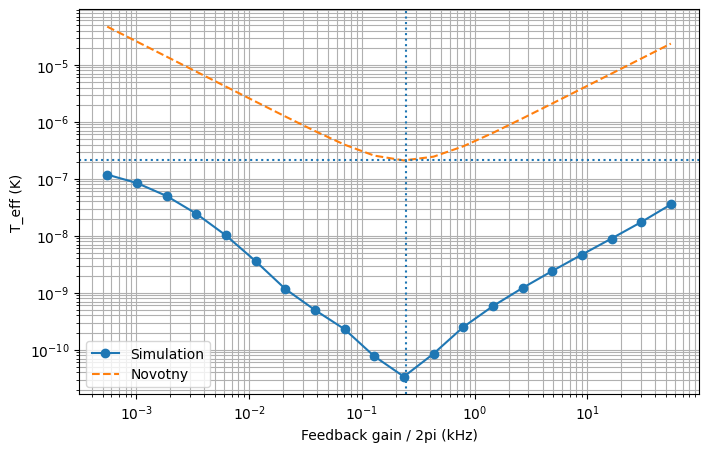

In [6]:
import numpy as np
#from paper
VX2 = np.mean(VX2_list)
# Snn = dt * VX2

# Snn = 1 / VX2
#vertical shift
# A = 1e-14 #vertial shift 
# C = 1400000 #proportionality constant between Snn and alpha_s nosie squared (this shifts it horizontaly only )
C = 1/7
Snn = C*(1/(8*eta*kappa))#measurement noise (imprecision noise) alpha
Sff = (1 / (eta)) * (1/((4 * np.pi)**2 * Snn))
#finding Snn using relation between Snn and Sff given imprecision product did not work lol 
T_theory = []
for g_fb in gammas:
    T = np.pi*(Sff/g_fb + g_fb*Snn)*T0 
    T_theory.append(T)

T_min = 2*np.pi*np.sqrt(Sff*Snn)*T0
g_opt = np.sqrt(Sff/Snn)

#converting gain of paper to units
omega_m = 2*np.pi*55e3
g_pap = gammas*omega_m/(2*np.pi)/1e3


plt.figure(figsize=(8,5))
plt.loglog(g_pap, T_list, 'o-', label='Simulation')
plt.loglog(g_pap, T_theory, '--', label='Novotny')
plt.axhline(T_min, linestyle=':')
plt.axvline(g_opt*omega_m/(2*np.pi)/1e3, linestyle=':')
plt.xlabel("Feedback gain / 2pi (kHz)")
plt.ylabel("T_eff (K)")
plt.legend()
plt.grid(True, which='both')
plt.show()

For g<g_opt Sff dominates and for g>g_opt Snn dominates? 
So an optimal feedback gain occurs when you've balanced Sff and Snn


if Sff dominates g<g_opt regime then it  is nonlinear?


For g<g_opt the fluctuating force takes a longer time to reach a stedy state... has to do with Q factor. Temp from simulation comes from integral udner x trajectory psd. 

I guess now i can move on to tyring to cool  by modulating the beam center: from what giacamo said it WAS F = -gamma * xdot, still want same force by the way I should aply will now need measurement of posiiton instead of just velocoty ... before i would detect position and use it's derivative only to define the force update in the momentum <p>.... now i want the position and the velocoty so i can move the beam center itself.. now i am chanign the posiiton of the beam center. measurement uncertainty in position will also matter.. but didn't i tmatter before? 

Maybe do this F = - k(x-xc) where alpha is really x and get F = -gamma * alpha dot

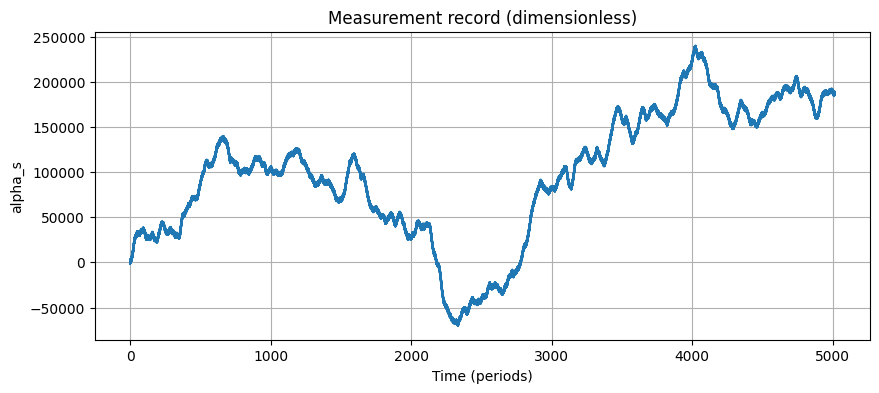

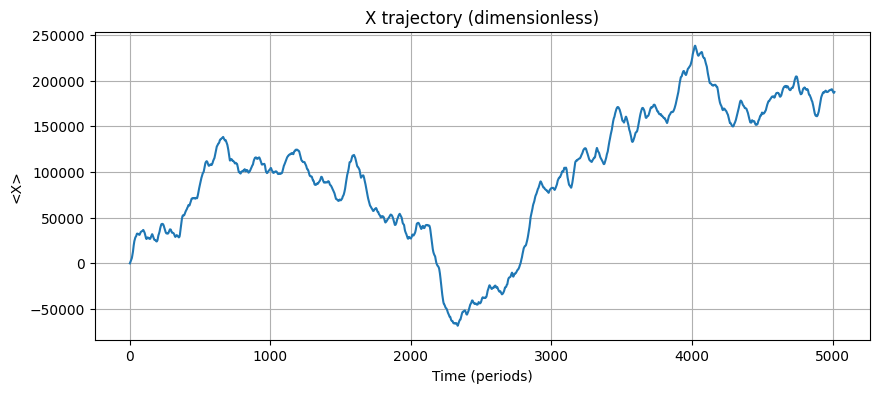

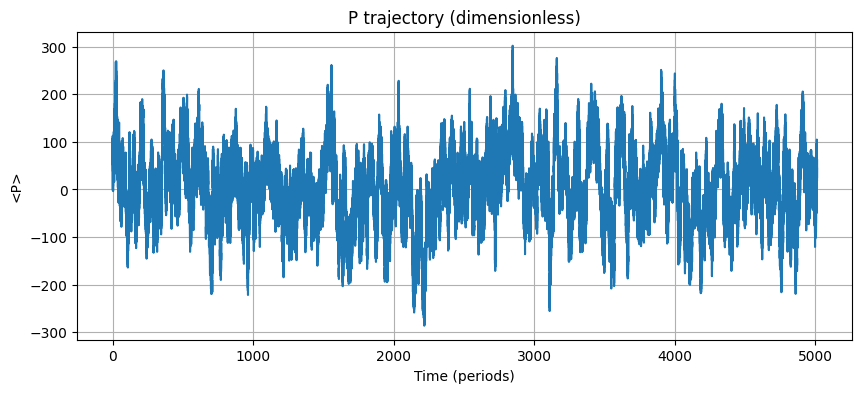

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

#resonance requency over gamma is quality favotr tell syou how many periods
hbar = 1.0
m = 1.0
omega0 = 1.0
x0 = np.sqrt(hbar / (m * omega0))
p0 = np.sqrt(hbar * m * omega0)
t0 = 1 / omega0

gamma_sc = 0.01
eta = 1.0
kappa = 1e-3

# feedback
gamma_fb = 1/100
window = 1

dt_prime = 0.0005
n_steps = int(6.3e7)  


#numba accelerted loop

@njit
def run_sim(n_steps, dt_prime, gamma_fb, window, eta, kappa):

    # Initial conditions
    X = 10.0
    P = 10.0
    VX = 1.0
    VP = 1.0
    CXP = 0.0

    # Storage
    X_traj = np.zeros(n_steps)
    P_traj = np.zeros(n_steps)
    VX_traj = np.zeros(n_steps)
    VP_traj = np.zeros(n_steps)
    CXP_traj = np.zeros(n_steps)
    X2_traj = np.zeros(n_steps)
    alpha_s_history = np.zeros(n_steps)

    for i in range(n_steps - 1):

        
        dW = np.random.randn() * np.sqrt(dt_prime)

        X += P * dt_prime + np.sqrt(8 * eta * kappa) * VX * dW

        # Measurement record
        alpha_s = X + dW / (np.sqrt(8 * eta * kappa)* dt_prime)
        alpha_s_history[i+1] = alpha_s

        if i > window:
            adot = (alpha_s_history[i] - alpha_s_history[i - window]) / (window * dt_prime)

            #beam center that implements viscous forceand depends on position 
            x_c = alpha_s - gamma_fb * adot
        else:
            x_c = 0.0 #beam center at 0 before apply feedbakck measurement
        #bead moves according to its real position but the force update can only come from measurement so use alpha in x_c
        P += -(X -x_c)* dt_prime + np.sqrt(8 * eta * kappa) * CXP * dW

        VX += (2 * CXP - 8 * eta * kappa * VX**2) * dt_prime
        VP += (-2 * CXP + 2 * kappa - 8 * eta * kappa * CXP**2) * dt_prime
        CXP += (VP - VX - 8 * eta * kappa * VX * CXP) * dt_prime

        X2 = X**2 + VX

        X_traj[i+1] = X
        P_traj[i+1] = P
        VX_traj[i+1] = VX
        VP_traj[i+1] = VP
        CXP_traj[i+1] = CXP
        X2_traj [i+1] = X2



    return X_traj, P_traj, VX_traj, VP_traj, CXP_traj, X2_traj, alpha_s_history



out = run_sim(n_steps, dt_prime, gamma_fb, window, eta, kappa)
X_traj, P_traj, VX_traj, VP_traj, CXP_traj, X2_traj, alpha_s_history = out

time = np.arange(n_steps) * dt_prime
time_periods = time / (2 * np.pi)

plt.figure(figsize=(10, 4))
plt.plot(time_periods, alpha_s_history)
plt.title("Measurement record (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("alpha_s")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_periods, X_traj)
plt.title("X trajectory (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("<X>")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_periods, P_traj)
plt.title("P trajectory (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("<P>")
plt.grid(True)
plt.show()

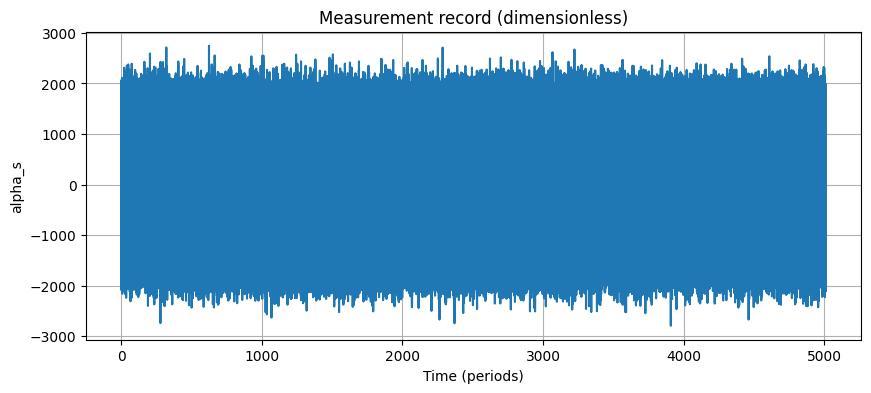

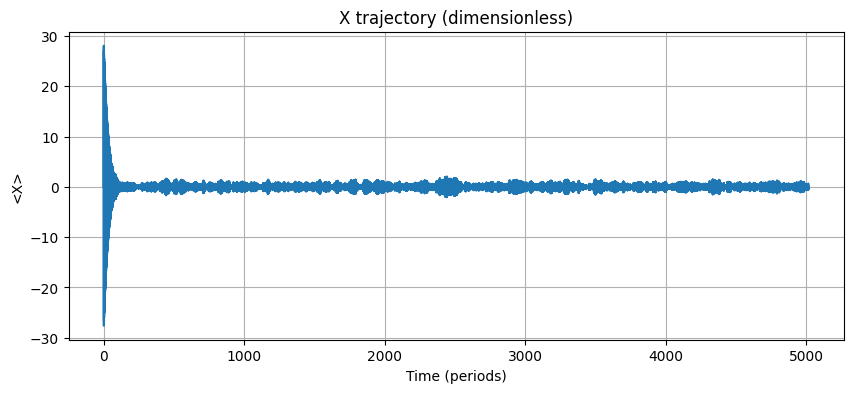

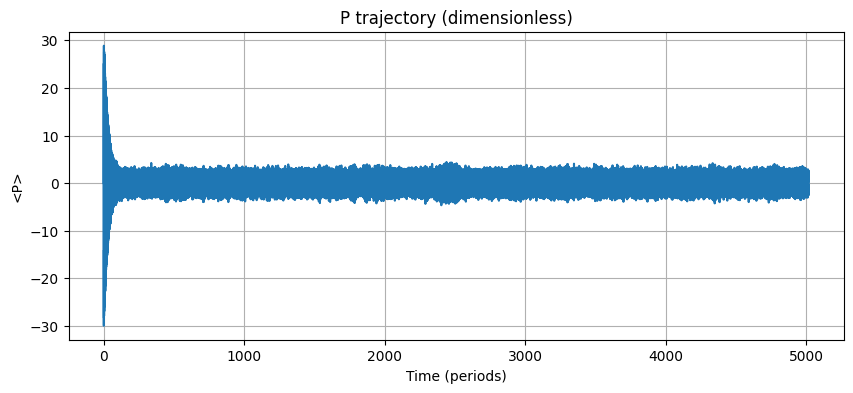

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

hbar = 1.0
m = 1.0
omega0 = 1.0
x0 = np.sqrt(hbar / (m * omega0))
p0 = np.sqrt(hbar * m * omega0)
t0 = 1 / omega0

eta = 1.0
kappa = 1e-3
#Q = omega0 / gammafb
# feedback
gamma_fb = 1e-2
#gamma_fb = 0
dt_prime = 0.0005
n_steps = int(6.3e7)
window = 50 


@njit
def run_sim(n_steps, dt_prime, gamma_fb, eta, kappa):

    # Initial conditions
    X = 20.0
    P = 20.0
    VX = 1.0
    VP = 1.0
    CXP = 0.0


    root_8ek = np.sqrt(8.0 * eta * kappa)
    sqrt_dt  = np.sqrt(dt_prime)

    # Storage
    X_traj          = np.zeros(n_steps)
    P_traj          = np.zeros(n_steps)
    VX_traj         = np.zeros(n_steps)
    VP_traj         = np.zeros(n_steps)
    CXP_traj        = np.zeros(n_steps)
    X2_traj         = np.zeros(n_steps)
    alpha_s_history = np.zeros(n_steps)

    for i in range(n_steps - 1):

        dW = np.random.randn() * sqrt_dt


        X += P * dt_prime + root_8ek * VX * dW
        alpha_s = X + dW / (root_8ek * dt_prime)
        alpha_s_history[i+1] = alpha_s
        
        if i > window:
            adot = (alpha_s_history[i] - alpha_s_history[i - window]) / (window * dt_prime)
            x_c = -gamma_fb* adot 
        
        P += -(X - x_c) * dt_prime + root_8ek * CXP * dW
        VX  += (2.0 * CXP - 8.0 * eta * kappa * VX**2) * dt_prime
        VP  += (-2.0 * CXP + 2.0 * kappa - 8.0 * eta * kappa * CXP**2) * dt_prime
        CXP += (VP - VX - 8.0 * eta * kappa * VX * CXP) * dt_prime

        X2 = X**2 + VX

        X_traj[i+1]          = X
        P_traj[i+1]          = P
        VX_traj[i+1]         = VX
        VP_traj[i+1]         = VP
        CXP_traj[i+1]        = CXP
        X2_traj[i+1]         = X2


    return X_traj, P_traj, VX_traj, VP_traj, CXP_traj, X2_traj, alpha_s_history


out = run_sim(n_steps, dt_prime, gamma_fb, eta, kappa)
X_traj, P_traj, VX_traj, VP_traj, CXP_traj, X2_traj, alpha_s_history = out

time = np.arange(n_steps) * dt_prime
time_periods = time / (2 * np.pi)

plt.figure(figsize=(10, 4))
plt.plot(time_periods, alpha_s_history)
plt.title("Measurement record (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("alpha_s")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_periods, X_traj)
plt.title("X trajectory (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("<X>")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_periods, P_traj)
plt.title("P trajectory (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("<P>")
plt.grid(True)
plt.show()

Before was doing $F_{trap} = -k(x-x_c)$ set equal to $F_{fb} = -\gamma * x$ equal to eachother when you really want total force to be $F = F_{trap} + F_{fb}$  not just $F_{trap}$ with an $x_c$


So now doing $F_{total} = -k(X-x_c) -\gamma * X$
so $x_c$ is $= -\gamma * X$


Currently moving faster than repsnse time of oscillator 

How quickly can cool and how low temp can go 

For now look for optimal feedback gain.. if wanna minimizefinal temp what's optimal gain? and what is minumum temp

Stars mar 3

/var/folders/pg/vxw1kc2j4msgjcv3j7s6ws940000gn/T/ipykernel_10151/2808267450.py:64: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  var_x = simps(Pxx, f)


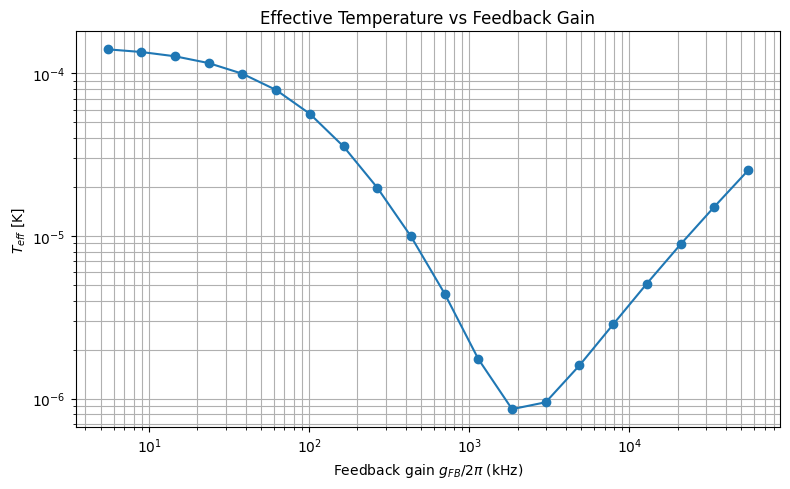

In [7]:
import numpy as np
from scipy.signal import welch 
from scipy.integrate import simps
import matplotlib.pyplot as plt
from numba import njit

eta = 1.0
kappa = 1e-3
window = 20
n_steps = int(2.5e6)
dt = 0.05
omega0 = 55e3
hbar = 6.62607015e-34 / (2 * np.pi)
kB = 1.380649e-23
T0 = hbar * omega0 / kB
root_8ek = np.sqrt(eta * 8 * kappa)
dt_prime = 0.0005

@njit
def simulate_trajectory(g_fb, dW_all, n_steps, dt_prime, eta, kappa, window):
    X = 20.0
    P = 20.0
    VX = 1.0
    VP = 1.0
    CXP = 0.0

    X_traj = np.zeros(n_steps)
    alpha_s_history = np.zeros(n_steps + 1)
    root_term = np.sqrt(8.0 * eta * kappa)
    x_c = 0.0

    for i in range(n_steps):
        dW = dW_all[i]

        X += P * dt_prime + root_term * VX * dW

        alpha_s = X + dW / (root_term * dt_prime) if (root_term * dt_prime) != 0.0 else X
        alpha_s_history[i + 1] = alpha_s  #agaisnt div by 0

        if i > window:
            adot = (alpha_s_history[i] - alpha_s_history[i - window]) / (window * dt_prime)
            x_c = -g_fb * adot

        P   += -(X - x_c) * dt_prime + root_term * CXP * dW
        VX  += (2.0 * CXP - 8.0 * eta * kappa * VX**2) * dt_prime
        VP  += (-2.0 * CXP + 2.0 * kappa - 8.0 * eta * kappa * CXP**2) * dt_prime
        CXP += (VP - VX - 8.0 * eta * kappa * VX * CXP) * dt_prime

        X_traj[i] = X

    return X_traj


# Simulate multiple feedback gains
gammas = np.logspace(-4, 0, 20)
dW_all = np.random.randn(n_steps) * np.sqrt(dt_prime)
T_list = []

for g_fb in gammas:
    X_traj = simulate_trajectory(g_fb, dW_all, n_steps, dt_prime, eta, kappa, window)

    fs = 1.0 / dt
    f, Pxx = welch(X_traj, fs=fs, nperseg=len(X_traj) // 4)
    var_x = simps(Pxx, f)
    T_list.append(var_x * T0)


omega_m = 2 * np.pi * 55e3
gamma_FB = gammas * omega_m
g_pap = gamma_FB / (2 * np.pi) # kHz

plt.figure(figsize=(8, 5))
plt.loglog(g_pap, T_list, 'o-')
plt.xlabel("Feedback gain $g_{FB} / 2\\pi$ (kHz)")
plt.ylabel("$T_{eff}$ [K]")
plt.title("Effective Temperature vs Feedback Gain")
plt.grid(True, which='both')
plt.tight_layout()
plt.show()

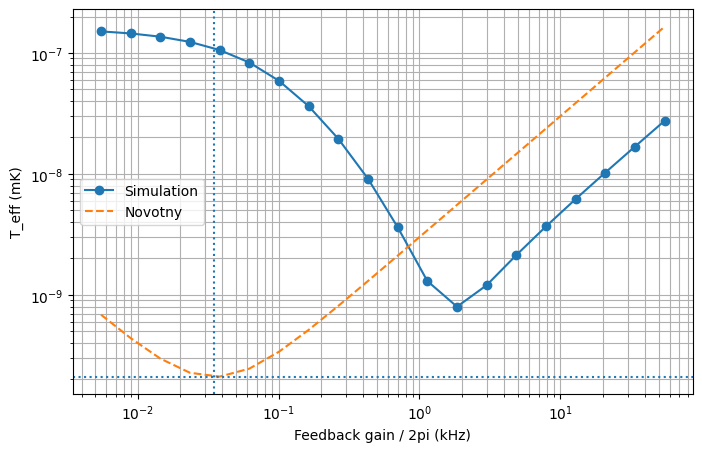

In [16]:
import numpy as np
#from paper
# Snn = dt * VX2

# Snn = 1 / VX2
#vertical shift
Snn = (1/(8*eta*kappa))#measurement noise (imprecision noise) alpha
Sff = (1 / (eta)) * (1/((4 * np.pi)**2 * Snn))
#finding Snn using relation between Snn and Sff given imprecision product did not work lol 
T_theory = []
for g_fb in gammas:
    T = np.pi*(Sff/g_fb + g_fb*Snn)*T0 /1e3
    T_theory.append(T)

T_min = 2*np.pi*np.sqrt(Sff*Snn)*T0 /1e3
g_opt = np.sqrt(Sff/Snn) 

#converting gain of paper to units
omega_m = 2*np.pi*55e3
g_pap = gammas*omega_m/(2*np.pi)/1e3


plt.figure(figsize=(8,5))
plt.loglog(g_pap, T_list, 'o-', label='Simulation')
plt.loglog(g_pap, T_theory, '--', label='Novotny')
plt.axhline(T_min, linestyle=':')
plt.axvline(g_opt*omega_m/(2*np.pi)/1e3, linestyle=':')
plt.xlabel("Feedback gain / 2pi (kHz)")
plt.ylabel("T_eff (mK)")
plt.legend()
plt.grid(True, which='both')
plt.show()

Now looping over differnt kappas:

/var/folders/pg/vxw1kc2j4msgjcv3j7s6ws940000gn/T/ipykernel_13089/2074134354.py:68: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  var_x  = simps(Pxx, f)


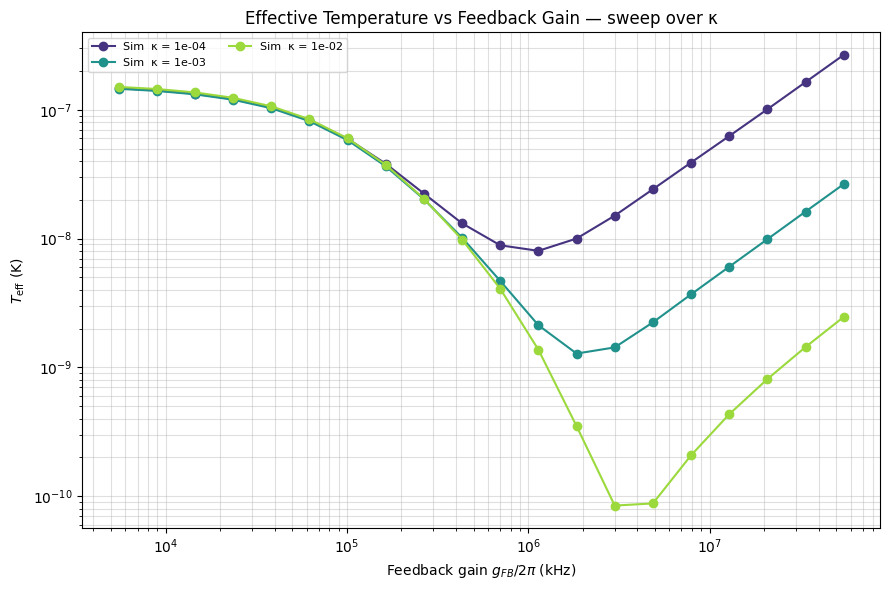

In [23]:
import numpy as np
from scipy.signal import welch
from scipy.integrate import simps
import matplotlib.pyplot as plt
from numba import njit

eta   = 1.0
window  = 20
n_steps = int(2.5e6)
dt      = 0.05
omega0  = 55e3
hbar    = 6.62607015e-34 / (2 * np.pi)
kB      = 1.380649e-23
T0      = hbar * omega0 / kB #try unit conversion that includes mass cuz epect min to be 1/2mw
dt_prime = 0.0005

@njit
def simulate_trajectory(g_fb, dW_all, n_steps, dt_prime, eta, kappa, window):
    X, P   = 20.0, 20.0
    VX, VP = 1.0,  1.0
    CXP    = 0.0

    X_traj          = np.zeros(n_steps)
    alpha_s_history = np.zeros(n_steps + 1)
    root_term       = np.sqrt(8.0 * eta * kappa)
    x_c             = 0.0

    for i in range(n_steps):
        dW = dW_all[i]

        X += P * dt_prime + root_term * VX * dW
        alpha_s = X + dW / (root_term * dt_prime) if (root_term * dt_prime) != 0.0 else X
        alpha_s_history[i + 1] = alpha_s

        if i > window:
            adot = (alpha_s_history[i] - alpha_s_history[i - window]) / (window * dt_prime)
            x_c  = -g_fb * adot

        P   += -(X - x_c) * dt_prime + root_term * CXP * dW
        VX  += (2.0 * CXP - 8.0 * eta * kappa * VX**2) * dt_prime
        VP  += (-2.0 * CXP + 2.0 * kappa - 8.0 * eta * kappa * CXP**2) * dt_prime
        CXP += (VP - VX - 8.0 * eta * kappa * VX * CXP) * dt_prime

        X_traj[i] = X

    return X_traj


gammas = np.logspace(-4, 0, 20)
kappas = [1e-4, 1e-3, 1e-2]          # sweep over measurement rates
dW_all = np.random.randn(n_steps) * np.sqrt(dt_prime)   # shared noise realization

omega_m = 2 * np.pi * omega0
g_pap   = gammas * omega_m / (2 * np.pi) * 1e3          # kHz axis

colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(kappas)))

fig, ax = plt.subplots(figsize=(9, 6))

for color, kappa in zip(colors, kappas):

    # ── simulation ──────────────────────────────────────────────────────────
    T_list = []
    for g_fb in gammas:
        X_traj = simulate_trajectory(g_fb, dW_all, n_steps, dt_prime, eta, kappa, window)
        fs     = 1.0 / dt
        f, Pxx = welch(X_traj, fs=fs, nperseg=len(X_traj) // 4)
        var_x  = simps(Pxx, f)
        T_list.append(var_x * T0 / 1e3)

    # ── theory (Novotný) ─────────────────────────────────────────────────────
    Snn = (1/(8*eta*kappa))#measurement noise (imprecision noise) alpha
    Sff = (1 / (eta)) * (1/((4 * np.pi)**2 * Snn))
    T_theory = [np.pi * (Sff / g + g * Snn) * T0  for g in gammas]
    T_min    = 2 * np.pi * np.sqrt(Sff * Snn) * T0 
    g_opt    = np.sqrt(Sff / Snn) * omega_m / (2 * np.pi)   # kHz

    label = f"κ = {kappa:.0e}"
    ax.loglog(g_pap, T_list,   'o-',  color=color, label=f"Sim  {label}")
    # ax.loglog(g_pap, T_theory, '--',  color=color, label=f"Theory {label}")
    # ax.axhline(T_min,  color=color, linestyle=':',  linewidth=0.8)
    # ax.axvline(g_opt,  color=color, linestyle=':',  linewidth=0.8)

ax.set_xlabel(r"Feedback gain $g_{FB}/2\pi$ (kHz)")
ax.set_ylabel(r"$T_\mathrm{eff}$ (K)")
ax.set_title("Effective Temperature vs Feedback Gain — sweep over κ")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, which='both', alpha=0.4)
fig.tight_layout()
plt.show()

Plot the psds and set axis lines for the limits of integration... amke sure imprecision noise is included

and upload to git hub


use more relaistic value sof eta like .1 and see how it changes things

unit vcovnersion to temp with mass to geet 1/2mw

make seperate branch 


End mar 3

Begin march 8th

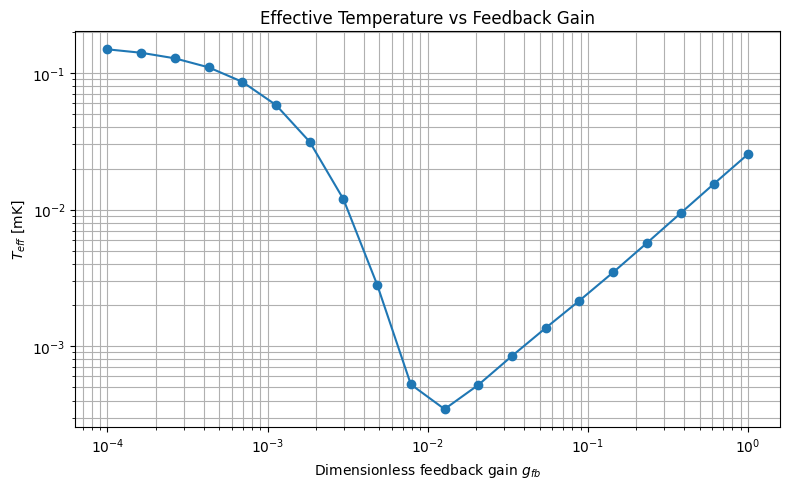

In [15]:
import numpy as np
from scipy.integrate import simps
import matplotlib.pyplot as plt
from numba import njit

eta = 1.0
kappa = 1e-3
window = 20
n_steps = int(2.5e6)
dt_prime = 0.0005
omega0 = 55e3
hbar = 6.62607015e-34 / (2 * np.pi)
kB = 1.380649e-23
T0 = hbar * omega0 / kB  # ℏω/kB in Kelvin

@njit
def simulate_trajectory(g_fb, dW_all, n_steps, dt_prime, eta, kappa, window):
    X = 20.0
    P = 20.0
    VX = 1.0
    VP = 1.0
    CXP = 0.0

    X_traj = np.zeros(n_steps)
    VX_traj = np.zeros(n_steps)  # track conditional variance
    alpha_s_history = np.zeros(n_steps + 1)
    root_term = np.sqrt(8.0 * eta * kappa)
    x_c = 0.0

    for i in range(n_steps):
        dW = dW_all[i]

        X += P * dt_prime + root_term * VX * dW

        alpha_s = X + dW / (root_term * dt_prime) if (root_term * dt_prime) != 0.0 else X
        alpha_s_history[i + 1] = alpha_s

        if i > window:
            adot = (alpha_s_history[i] - alpha_s_history[i - window]) / (window * dt_prime)
            x_c = -g_fb * adot

        P   += -(X - x_c) * dt_prime + root_term * CXP * dW
        VX  += (2.0 * CXP - 8.0 * eta * kappa * VX**2) * dt_prime
        VP  += (-2.0 * CXP + 2.0 * kappa - 8.0 * eta * kappa * CXP**2) * dt_prime
        CXP += (VP - VX - 8.0 * eta * kappa * VX * CXP) * dt_prime

        X_traj[i] = X
        VX_traj[i] = VX  # store conditional variance

    return X_traj, VX_traj


# Simulate multiple feedback gains
gammas = np.logspace(-4, 0, 20)
dW_all = np.random.randn(n_steps) * np.sqrt(dt_prime)
T_list_beam = []

for g_fb in gammas:
    X_traj, VX_traj = simulate_trajectory(g_fb, dW_all, n_steps, dt_prime, eta, kappa, window)

    half = n_steps // 2  # discard first half until reaches stead state

    #<X^2> = X(t)^2 + VX
    var_total = np.mean(X_traj[half:]**2 + VX_traj[half:])

    # T_eff in mK
    T_mK = var_total * T0 * 1e3
    T_list_beam.append(T_mK)


plt.figure(figsize=(8, 5))
plt.loglog(gammas, T_list_beam, 'o-')
plt.xlabel("Dimensionless feedback gain $g_{fb}$")
plt.ylabel("$T_{eff}$ [mK]")
plt.title("Effective Temperature vs Feedback Gain")
plt.grid(True, which='both')
plt.tight_layout()
plt.show()

direct momentum update:

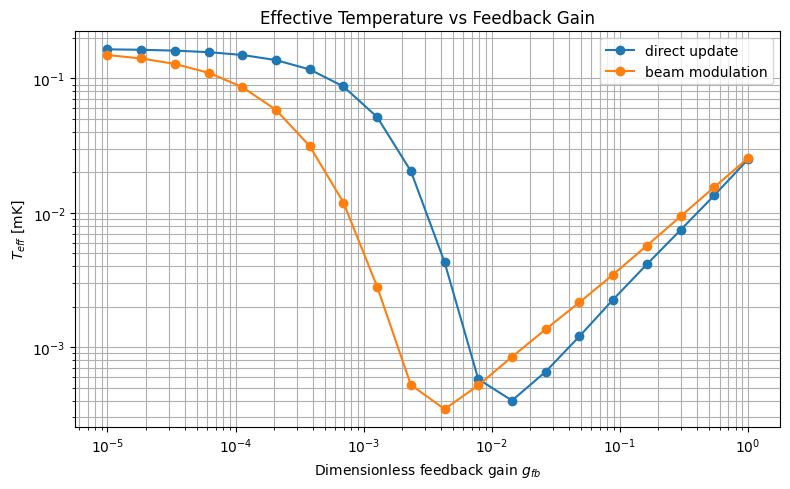

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

eta = 1.0
kappa = 1e-3
window = 20
n_steps = int(2.5e6)
dt = 0.0005
omega0 = 55e3
hbar = 6.62607015e-34 / (2 * np.pi)
kB = 1.380649e-23
T0 = hbar * omega0 / kB

@njit
def simulate_trajectory(g_fb, dW_all, n_steps, dt, eta, kappa, window):
    X = 20.0
    P = 20.0
    VX = 1.0
    VP = 1.0
    CXP = 0.0

    X_traj = np.zeros(n_steps, dtype=np.float64)
    VX_traj = np.zeros(n_steps, dtype=np.float64)
    alpha_s_history = np.zeros(n_steps + 1, dtype=np.float64)  # declared properly
    root_term = np.sqrt(8.0 * eta * kappa)

    for i in range(n_steps):
        dW = dW_all[i]

        X += P * dt + root_term * VX * dW
        P += -X * dt + root_term * CXP * dW
        VX  += (2.0 * CXP - 8.0 * eta * kappa * VX**2) * dt
        VP  += (-2.0 * CXP + 2.0 * kappa - 8.0 * eta * kappa * CXP**2) * dt
        CXP += (VP - VX - 8.0 * eta * kappa * VX * CXP) * dt

        X_traj[i] = X
        VX_traj[i] = VX

        alpha_s = X + dW / (root_term * dt)
        alpha_s_history[i + 1] = alpha_s

        if i > window:
            adot = (alpha_s_history[i] - alpha_s_history[i - window]) / (window * dt)
            P -= g_fb * adot * dt

    return X_traj, VX_traj


gammas = np.logspace(-5, 0, 20)
dW_all = np.random.randn(n_steps) * np.sqrt(dt)
T_list = []

for g_fb in gammas:
    X_traj, VX_traj = simulate_trajectory(g_fb, dW_all, n_steps, dt, eta, kappa, window)
    half = n_steps // 2

    var_total = np.mean(X_traj[half:]**2 + VX_traj[half:])
    T_list.append(var_total * T0 * 1e3)  

plt.figure(figsize=(8, 5))
plt.loglog(gammas, T_list, 'o-', label='direct update')
plt.loglog(gammas, T_list_beam, 'o-', label='beam modulation')
plt.xlabel("Dimensionless feedback gain $g_{fb}$")
plt.ylabel("$T_{eff}$ [mK]")
plt.title("Effective Temperature vs Feedback Gain")
plt.grid(True, which='both')
plt.legend()
plt.tight_layout()
plt.show()

Calculating temperature notes:
1) var_x is time averaged of X(t)^2 over stochastic trajectory -> includes 
the wandering of the mean and the quantum/shot fluctuations 
2) VX is just conditional quantum variance at each part 
3) taken together this means ⟨X^2⟩_total = mean(X_traj) + mean(VX)
4) ⟨X_opp²⟩ = X(t)² + VX(t) (guassian second moment stuff)
5) if you have a conditional mean X(t) and conditional variance VX(t), then the total variance is the variance of the conditional mean plus the mean of the conditional variance.The connection to temperature then comes from the equipartition theorem. (conditional requires prior info on the state)

Using PSDs to get temp

/var/folders/pg/vxw1kc2j4msgjcv3j7s6ws940000gn/T/ipykernel_10151/2652542311.py:71: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  mean_X2_traj = simps(Pxx, f)   #np.mean(X_traj^2)


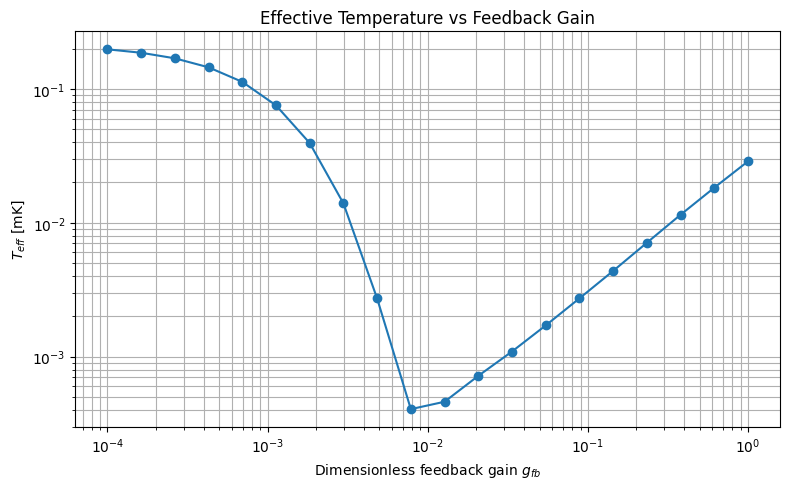

In [19]:
import numpy as np
from scipy.signal import welch
from scipy.integrate import simps
import matplotlib.pyplot as plt
from numba import njit

eta = 1.0
kappa = 1e-3
window = 20
n_steps = int(2.5e6)
dt_prime = 0.0005
omega0 = 55e3
hbar = 6.62607015e-34 / (2 * np.pi)
kB = 1.380649e-23
T0 = hbar * omega0 / kB

@njit
def simulate_trajectory(g_fb, dW_all, n_steps, dt_prime, eta, kappa, window):
    X = 20.0
    P = 20.0
    VX = 1.0
    VP = 1.0
    CXP = 0.0

    X_traj = np.zeros(n_steps, dtype=np.float64)
    VX_traj = np.zeros(n_steps, dtype=np.float64)
    alpha_s_history = np.zeros(n_steps + 1, dtype=np.float64)
    root_term = np.sqrt(8.0 * eta * kappa)
    x_c = 0.0

    for i in range(n_steps):
        dW = dW_all[i]

        X += P * dt_prime + root_term * VX * dW

        denom = root_term * dt_prime
        if denom != 0.0:
            alpha_s = X + dW / denom
        else:
            alpha_s = X

        alpha_s_history[i + 1] = alpha_s

        if i > window:
            adot = (alpha_s_history[i] - alpha_s_history[i - window]) / (window * dt_prime)
            x_c = -g_fb * adot

        P   += -(X - x_c) * dt_prime + root_term * CXP * dW
        VX  += (2.0 * CXP - 8.0 * eta * kappa * VX**2) * dt_prime
        VP  += (-2.0 * CXP + 2.0 * kappa - 8.0 * eta * kappa * CXP**2) * dt_prime
        CXP += (VP - VX - 8.0 * eta * kappa * VX * CXP) * dt_prime

        X_traj[i] = X
        VX_traj[i] = VX

    return X_traj, VX_traj


gammas = np.logspace(-4, 0, 20)
dW_all = np.random.randn(n_steps) * np.sqrt(dt_prime)
T_list_beam_2 = []
half = n_steps // 2

for g_fb in gammas:
    X_traj, VX_traj = simulate_trajectory(g_fb, dW_all, n_steps, dt_prime, eta, kappa, window)

    X_ss = X_traj[half:] #stead state ish
    VX_ss = VX_traj[half:]

    f, Pxx = welch(X_ss, fs=1.0/dt_prime, nperseg=len(X_ss)//4)
    mean_X2_traj = simps(Pxx, f)   #np.mean(X_traj^2)
    mean_X2_quantum = mean_X2_traj + np.mean(VX_ss)     #full quantum second moment
    T_mK = mean_X2_quantum * T0 * 1e3                   # convert to mK
    T_list_beam_2.append(T_mK)

plt.figure(figsize=(8, 5))
plt.loglog(gammas, T_list_beam_2, 'o-')
plt.xlabel("Dimensionless feedback gain $g_{fb}$")
plt.ylabel("$T_{eff}$ [mK]")
plt.title("Effective Temperature vs Feedback Gain")
plt.grid(True, which='both')
plt.tight_layout()
plt.show()

/var/folders/pg/vxw1kc2j4msgjcv3j7s6ws940000gn/T/ipykernel_10151/3553343467.py:62: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  mean_X2_traj = simps(Pxx, f)   #np.mean(X_traj^2)


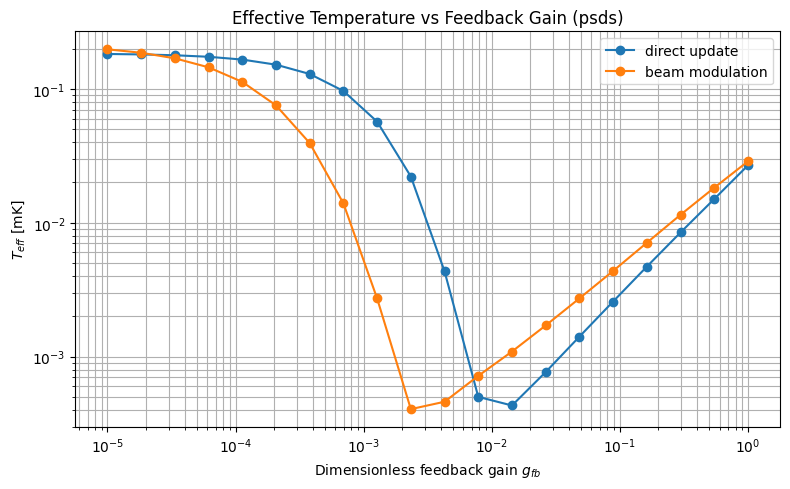

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

eta = 1.0
kappa = 1e-3
window = 20
n_steps = int(2.5e6)
dt = 0.0005
omega0 = 55e3
hbar = 6.62607015e-34 / (2 * np.pi)
kB = 1.380649e-23
T0 = hbar * omega0 / kB

@njit
def simulate_trajectory(g_fb, dW_all, n_steps, dt, eta, kappa, window):
    X = 20.0
    P = 20.0
    VX = 1.0
    VP = 1.0
    CXP = 0.0

    X_traj = np.zeros(n_steps, dtype=np.float64)
    VX_traj = np.zeros(n_steps, dtype=np.float64)
    alpha_s_history = np.zeros(n_steps + 1, dtype=np.float64)  # declared properly
    root_term = np.sqrt(8.0 * eta * kappa)

    for i in range(n_steps):
        dW = dW_all[i]

        X += P * dt + root_term * VX * dW
        P += -X * dt + root_term * CXP * dW
        VX  += (2.0 * CXP - 8.0 * eta * kappa * VX**2) * dt
        VP  += (-2.0 * CXP + 2.0 * kappa - 8.0 * eta * kappa * CXP**2) * dt
        CXP += (VP - VX - 8.0 * eta * kappa * VX * CXP) * dt

        X_traj[i] = X
        VX_traj[i] = VX

        alpha_s = X + dW / (root_term * dt)
        alpha_s_history[i + 1] = alpha_s

        if i > window:
            adot = (alpha_s_history[i] - alpha_s_history[i - window]) / (window * dt)
            P -= g_fb * adot * dt

    return X_traj, VX_traj


gammas = np.logspace(-5, 0, 20)
dW_all = np.random.randn(n_steps) * np.sqrt(dt)
T_list_2 = []

for g_fb in gammas:
    X_traj, VX_traj = simulate_trajectory(g_fb, dW_all, n_steps, dt, eta, kappa, window)
    half = n_steps // 2

    X_ss = X_traj[half:] #stead state ish
    VX_ss = VX_traj[half:]

    f, Pxx = welch(X_ss, fs=1.0/dt_prime, nperseg=len(X_ss)//4)
    mean_X2_traj = simps(Pxx, f)   #np.mean(X_traj^2)
    mean_X2_quantum = mean_X2_traj + np.mean(VX_ss)     #full quantum second moment
    T_mK = mean_X2_quantum * T0 * 1e3                   # convert to mK
    T_list_2.append(T_mK) 

plt.figure(figsize=(8, 5))
plt.loglog(gammas, T_list_2, 'o-', label='direct update')
plt.loglog(gammas, T_list_beam_2, 'o-', label='beam modulation')
plt.xlabel("Dimensionless feedback gain $g_{fb}$")
plt.ylabel("$T_{eff}$ [mK]")
plt.title("Effective Temperature vs Feedback Gain (psds)")
plt.grid(True, which='both')
plt.legend()
plt.tight_layout()
plt.show()

x_zpf = 5.638e-12 m
T0 = 2.640 μK
T_ground = 1.320 μK

Sanity check (g_fb=0):
<X^2> = 1.9880  (should be ~0.5)
T_baseline = 5.25 μK  (should be ~1.32 μK)


/var/folders/pg/vxw1kc2j4msgjcv3j7s6ws940000gn/T/ipykernel_10151/444636749.py:84: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  mean_X2_traj = simps(Pxx, f)


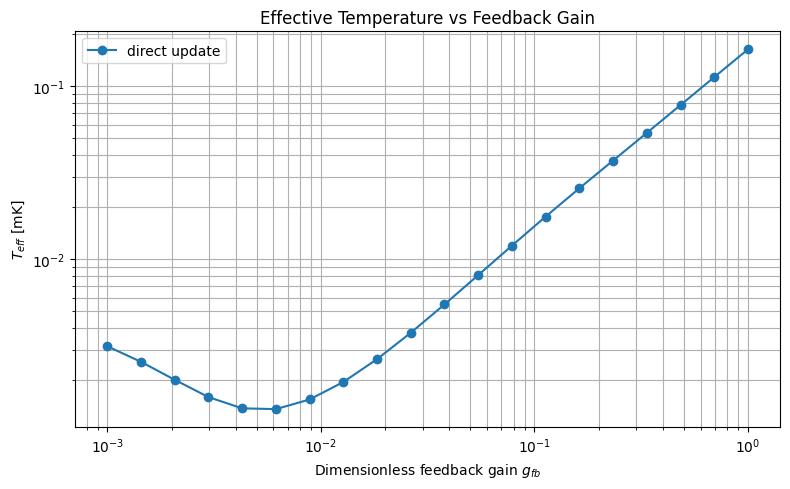

x_zpf = 5.638e-12 m
T0 = 2.640 μK
T_ground = 1.320 μK

Sanity check (g_fb=0):
<X^2> = 389.9977  (should be ~0.5)
T_baseline = 1029.43 μK  (should be ~1.32 μK)


/var/folders/pg/vxw1kc2j4msgjcv3j7s6ws940000gn/T/ipykernel_10151/1690752153.py:91: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  mean_X2_traj = simps(Pxx, f)


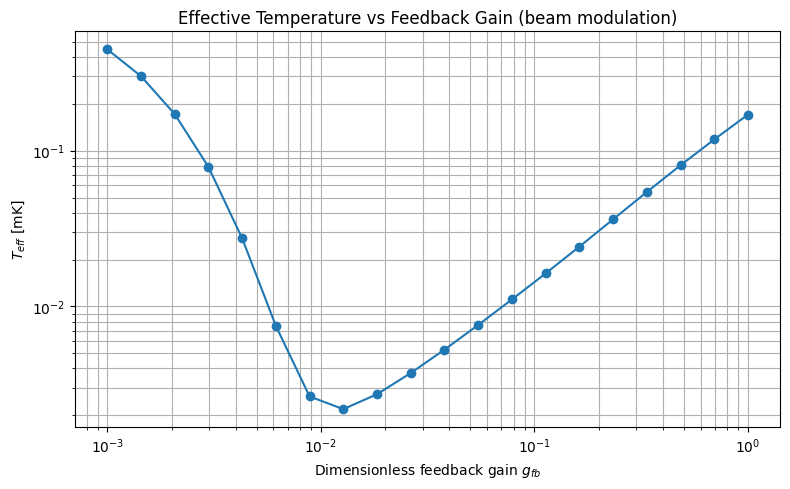

In [43]:
import numpy as np
from scipy.signal import welch
from scipy.integrate import simps
import matplotlib.pyplot as plt
from numba import njit

# Physical parameters
m = 4.8e-18          # kg (4.8 fg)
f0 = 55e3            # Hz
omega0 = 2*np.pi*f0  # rad/s
hbar = 6.62607015e-34 / (2 * np.pi)
kB = 1.380649e-23
x_full = np.sqrt(hbar / (2 * m * omega0))
T0 = hbar * omega0 / kB

print(f"x_full = {x_full:.3e} m")
print(f"T0 = {T0*1e6:.3f} μK")
print(f"T_ground = {T0/2*1e6:.3f} μK")

# Simulation parameters
eta = 1.0
kappa = 1e-3
window = 20
n_steps = int(2.5e6)
dt_prime = 0.0005

@njit
def simulate_trajectory(g_fb, dW_all, n_steps, dt_prime, eta, kappa, window):
    X = 20.0   # ground state initial conditions
    P = 20.0
    VX = 0.5  # ground state variance
    VP = 0.5
    CXP = 0.0

    X_traj = np.zeros(n_steps, dtype=np.float64)
    VX_traj = np.zeros(n_steps, dtype=np.float64)
    alpha_s_history = np.zeros(n_steps + 1, dtype=np.float64)
    root_term = np.sqrt(8.0 * eta * kappa)
    x_c = 0.0

    for i in range(n_steps):
        dW = dW_all[i]

        X += P * dt_prime + root_term * VX * dW

        denom = root_term * dt_prime
        if denom != 0.0:
            alpha_s = X + dW / denom
        else:
            alpha_s = X

        alpha_s_history[i + 1] = alpha_s

        if i > window:
            adot = (alpha_s_history[i] - alpha_s_history[i - window]) / (window * dt_prime)
            x_c = -g_fb * adot

        P   += -(X - x_c) * dt_prime + root_term * CXP * dW
        VX  += (2.0 * CXP - 8.0 * eta * kappa * VX**2) * dt_prime
        VP  += (-2.0 * CXP + 2.0 * kappa - 8.0 * eta * kappa * CXP**2) * dt_prime
        CXP += (VP - VX - 8.0 * eta * kappa * VX * CXP) * dt_prime

        X_traj[i] = X
        VX_traj[i] = VX

    return X_traj, VX_traj


# Sanity check at g_fb=0
dW_all = np.random.randn(n_steps) * np.sqrt(dt_prime)
half = n_steps // 2

X_traj, VX_traj = simulate_trajectory(0.0, dW_all, n_steps, dt_prime, eta, kappa, window)
X_ss, VX_ss = X_traj[half:], VX_traj[half:]
X2_base = np.mean(X_ss**2 + VX_ss)
print(f"\nSanity check (g_fb=0):")
print(f"<X^2> = {X2_base:.4f}  (should be ~0.5)")
print(f"T_baseline = {X2_base * T0 * 1e6:.2f} μK  (should be ~{T0/2*1e6:.2f} μK)")

# Simulate multiple feedback gains
gammas = np.logspace(-3, 0, 20)
T_list_beam_2 = []

for g_fb in gammas:
    X_traj, VX_traj = simulate_trajectory(g_fb, dW_all, n_steps, dt_prime, eta, kappa, window)

    X_ss = X_traj[half:]
    VX_ss = VX_traj[half:]

    f, Pxx = welch(X_ss, fs=1.0/dt_prime, nperseg=len(X_ss)//4)
    mean_X2_traj = simps(Pxx, f)
    mean_X2_quantum = mean_X2_traj + np.mean(VX_ss)
    T_mK = mean_X2_quantum * T0 * 1e3
    T_list_beam_2.append(T_mK)

plt.figure(figsize=(8, 5))
plt.loglog(gammas, T_list_beam_2, 'o-')
plt.xlabel("Dimensionless feedback gain $g_{fb}$")
plt.ylabel("$T_{eff}$ [mK]")
plt.title("Effective Temperature vs Feedback Gain (beam modulation)")
plt.grid(True, which='both')
plt.tight_layout()
plt.show()

T0 = 2.640 μK
T_ground = 1.320 μK


/var/folders/pg/vxw1kc2j4msgjcv3j7s6ws940000gn/T/ipykernel_10151/3768328096.py:84: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  mean_X2_traj = simps(Pxx, f)


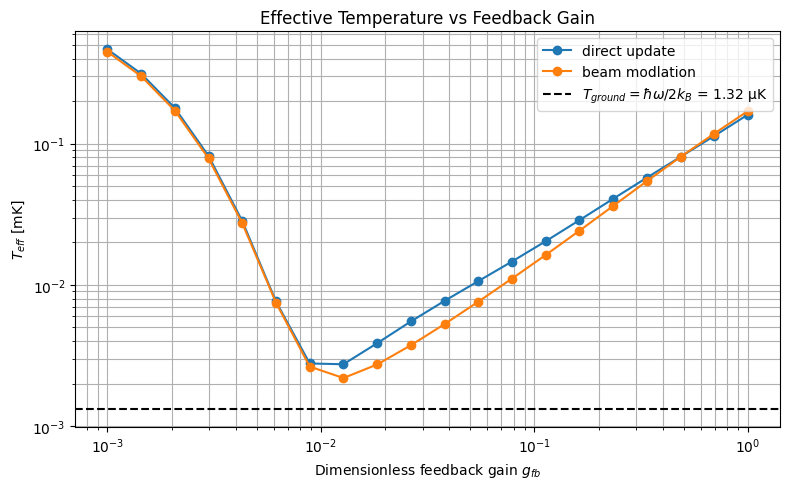

In [50]:
import numpy as np
from scipy.signal import welch
from scipy.integrate import simps
import matplotlib.pyplot as plt
from numba import njit

# Physical parameters
m = 4.8e-18          # kg (4.8 fg)
f0 = 55e3            # Hz
omega0 = 2*np.pi*f0  # rad/s
hbar = 6.62607015e-34 / (2 * np.pi)
kB = 1.380649e-23
x_full = np.sqrt(hbar / (2 * m * omega0))
T0 = hbar * omega0 / kB  # ℏω/kB in Kelvin

# print(f"x_full = {x_full:.3e} m")
print(f"T0 = {T0*1e6:.3f} μK")
print(f"T_ground = {T0/2*1e6:.3f} μK")

# Simulation parameters
eta = 1.0
kappa = 1e-3
window = 20
n_steps = int(2.5e6)
dt = 0.0005

@njit
def simulate_trajectory(g_fb, dW_all, n_steps, dt, eta, kappa, window):
    X = 20.0   # start at ground state, not X=20
    P = 20.0
    VX = 0.5  # ground state variance
    VP = 0.5
    CXP = 0.0

    X_traj = np.zeros(n_steps, dtype=np.float64)
    VX_traj = np.zeros(n_steps, dtype=np.float64)
    alpha_s_history = np.zeros(n_steps + 1, dtype=np.float64)
    root_term = np.sqrt(8.0 * eta * kappa)

    for i in range(n_steps):
        dW = dW_all[i]

        X += P * dt + root_term * VX * dW
        P += -X * dt + root_term * CXP * dW
        VX  += (2.0 * CXP - 8.0 * eta * kappa * VX**2) * dt
        VP  += (-2.0 * CXP + 2.0 * kappa - 8.0 * eta * kappa * CXP**2) * dt
        CXP += (VP - VX - 8.0 * eta * kappa * VX * CXP) * dt

        X_traj[i] = X
        VX_traj[i] = VX

        alpha_s = X + dW / (root_term * dt)
        alpha_s_history[i + 1] = alpha_s

        if i > window:
            adot = (alpha_s_history[i] - alpha_s_history[i - window]) / (window * dt)
            P -= g_fb * adot * dt

    return X_traj, VX_traj


# Sanity check at g_fb=0
dW_all = np.random.randn(n_steps) * np.sqrt(dt)
half = n_steps // 2

X_traj, VX_traj = simulate_trajectory(0.0, dW_all, n_steps, dt, eta, kappa, window)
X_ss, VX_ss = X_traj[half:], VX_traj[half:]
X2_base = np.mean(X_ss**2 + VX_ss)
# print(f"\nSanity check (g_fb=0):")
# print(f"<X^2> = {X2_base:.4f}  (should be ~0.5)")
# print(f"T_baseline = {X2_base * T0 * 1e6:.2f} μK  (should be ~{T0/2*1e6:.2f} μK)")

# Simulate multiple feedback gains
gammas = np.logspace(-3, 0, 20)
T_list = []

for g_fb in gammas:
    X_traj, VX_traj = simulate_trajectory(g_fb, dW_all, n_steps, dt, eta, kappa, window)

    X_ss = X_traj[half:]
    VX_ss = VX_traj[half:]

    f, Pxx = welch(X_ss, fs=1.0/dt, nperseg=len(X_ss)//4)
    mean_X2_traj = simps(Pxx, f)
    mean_X2_quantum = mean_X2_traj + np.mean(VX_ss)  # full quantum second moment

    # equipartition: T = m*omega0^2*x_full^2*<X^2>/kB = T0*<X^2>
    # valid only if X  <X^2>=0.5 at baseline
    T_mK = mean_X2_quantum * T0 * 1e3
    T_list.append(T_mK)

plt.figure(figsize=(8, 5))
plt.loglog(gammas, T_list, 'o-', label='direct update')
plt.loglog(gammas, T_list_beam_2, 'o-', label = 'beam modlation')
plt.xlabel("Dimensionless feedback gain $g_{fb}$")
plt.ylabel("$T_{eff}$ [mK]")
plt.title("Effective Temperature vs Feedback Gain")
T_ground_mK = (T0 / 2) * 1e3  # ℏω/2kB in mK
plt.axhline(T_ground_mK, color='k', linestyle='--', label=f'$T_{{ground}} = \\hbar\\omega/2k_B$ = {T_ground_mK*1e3:.2f} μK')
plt.grid(True, which='both')
plt.legend()
plt.tight_layout()
plt.show()

end march 8 

Beginning march 10

T0 = 2.640 μK
T_ground = 1.320 μK


/var/folders/pg/vxw1kc2j4msgjcv3j7s6ws940000gn/T/ipykernel_8968/1608704028.py:88: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  mean_X2_traj = simps(Pxx, f)


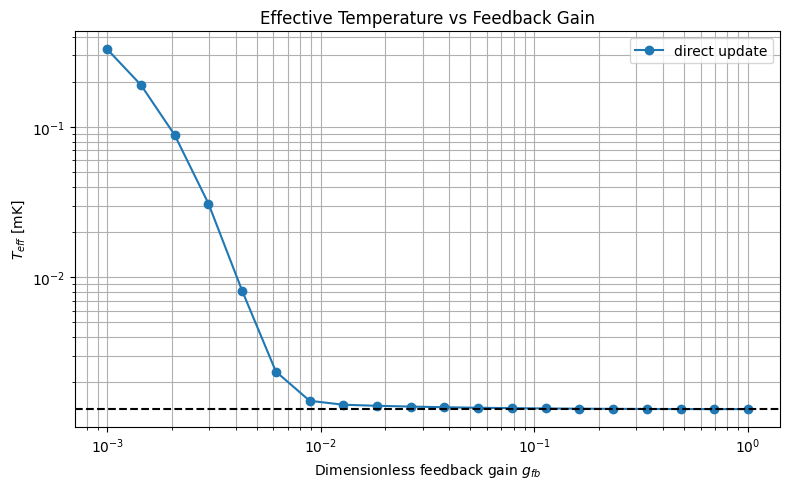

In [2]:
import numpy as np
from scipy.signal import welch
from scipy.integrate import simps
import matplotlib.pyplot as plt
from numba import njit

# Physical parameters
m = 4.8e-18          # kg (4.8 fg)
f0 = 55e3            # Hz
omega0 = 2*np.pi*f0  # rad/s
hbar = 6.62607015e-34 / (2 * np.pi)
kB = 1.380649e-23
T0 = hbar * omega0 / kB  # ℏω/kB in Kelvin

# print(f"x_full = {x_full:.3e} m")
print(f"T0 = {T0*1e6:.3f} μK")
print(f"T_ground = {T0/2*1e6:.3f} μK")

# Simulation parameters
eta = 1.0
kappa = 1e-3
window = 20
n_steps = int(2.5e6)
dt = 0.0005
g_fb = 1/100

# K21 = np.sqrt(1 + g_fb**2) - 1
# K22 = np.sqrt(g_fb**2 - 2 + 2 * np.sqrt(1 + g_fb**2))

@njit
def simulate_trajectory(g_fb, dW_all, n_steps, dt, eta, kappa, window):
    X = 20.0
    P = 20.0
    VX = 0.5
    VP = 0.5
    CXP = 0.0

    #from giacomo matrix with omega = 1
    K21 = np.sqrt(1 + g_fb**2) - 1
    K22 = np.sqrt(g_fb**2 - 2 + 2 * np.sqrt(1 + g_fb**2))

    X_traj = np.zeros(n_steps)
    VX_traj = np.zeros(n_steps)
    root_term = np.sqrt(8 * eta * kappa)

    for i in range(n_steps):
        dW = dW_all[i]

        # Kalman filter update (conditional means + covariances)
        X += P * dt + root_term * VX * dW
        P += -X * dt + root_term * CXP * dW
        VX  += (2.0 * CXP - 8.0 * eta * kappa * VX**2) * dt
        VP  += (-2.0 * CXP + 2.0 * kappa - 8.0 * eta * kappa * CXP**2) * dt
        CXP += (VP - VX - 8.0 * eta * kappa * VX * CXP) * dt

        # LQR feedback: u = -K * [X, P]^T, force acts on momentum
        u = -(K21 * X + K22 * P)
        P += u * dt

        X_traj[i] = X
        VX_traj[i] = VX

    return X_traj, VX_traj


# Sanity check at g_fb=0
dW_all = np.random.randn(n_steps) * np.sqrt(dt)
half = n_steps // 2

# X_traj, VX_traj = simulate_trajectory(0.0, dW_all, n_steps, dt, eta, kappa, window)
# X_ss, VX_ss = X_traj[half:], VX_traj[half:]
# X2_base = np.mean(X_ss**2 + VX_ss)
# print(f"\nSanity check (g_fb=0):")
# print(f"<X^2> = {X2_base:.4f}  (should be ~0.5)")
# print(f"T_baseline = {X2_base * T0 * 1e6:.2f} μK  (should be ~{T0/2*1e6:.2f} μK)")

# Simulate multiple feedback gains
gammas = np.logspace(-3, 0, 20)
T_list = []

for g_fb in gammas:
    X_traj, VX_traj = simulate_trajectory(g_fb, dW_all, n_steps, dt, eta, kappa, window)

    X_ss = X_traj[half:]
    VX_ss = VX_traj[half:]

    f, Pxx = welch(X_ss, fs=1.0/dt, nperseg=len(X_ss)//4)
    mean_X2_traj = simps(Pxx, f)
    mean_X2_quantum = mean_X2_traj + np.mean(VX_ss)  # full quantum second moment

    # equipartition: T = m*omega0^2*x_full^2*<X^2>/kB = T0*<X^2>
    # valid only if X  <X^2>=0.5 at baseline
    T_mK = mean_X2_quantum * T0 * 1e3
    T_list.append(T_mK)

plt.figure(figsize=(8, 5))
plt.loglog(gammas, T_list, 'o-', label='direct update')
# plt.loglog(gammas, T_list_beam_2, 'o-', label = 'beam modlation')
plt.xlabel("Dimensionless feedback gain $g_{fb}$")
plt.ylabel("$T_{eff}$ [mK]")
plt.title("Effective Temperature vs Feedback Gain")
T_ground_mK = (T0 / 2) * 1e3  # ℏω/2kB in mK
plt.axhline(T_ground_mK, color='k', linestyle='--')
plt.grid(True, which='both')
plt.legend()
plt.tight_layout()
plt.show()

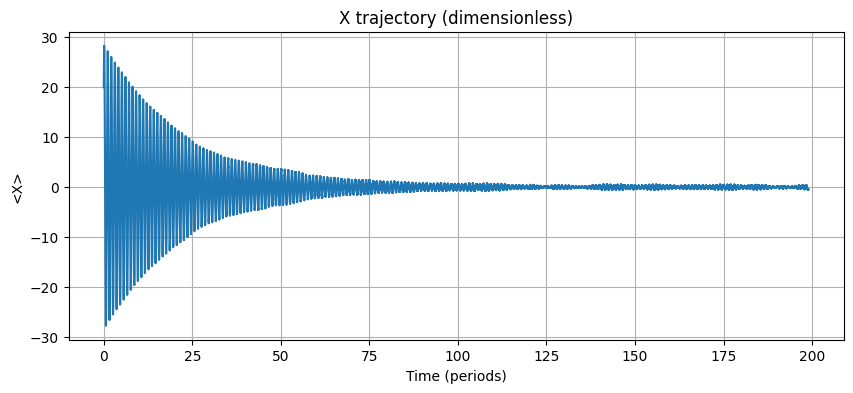

NameError: name 'P_traj' is not defined

<Figure size 1000x400 with 0 Axes>

In [19]:
time = np.arange(n_steps) * dt
time_periods = time / (2 * np.pi)


plt.figure(figsize=(10, 4))
plt.plot(time_periods, X_traj)
plt.title("X trajectory (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("<X>")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_periods, P_traj)
plt.title("P trajectory (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("<P>")
plt.grid(True)
plt.show()

T0       = 2.640 μK
T_ground = 1.320 μK

Nanoparticle volume V = 2.3951e-21 m^3
Polarizability alpha' = 1.5423e-32 C·m^2/V  (1.5423e-32 F·m^2)
Peak intensity I0    = 6.6858e+11 W/m^2  (~6.69 x 10^11)
Trap depth V0        = 2.5779e-21 J

Harmonic scale 1/m^2 : 5.5591e+13 1/m^2
Equivalent w_0 check : 1/w_x^2 = 2.1004e+12 1/m^2  (should match)
Ratio harm_scale/1/w_x^2 = 26.4669  (should be ~1 in harmonic approx)

x_zpf = 5.6381e-12 m  =  0.0008% of w_x
Harmonic scale (sim units): 1.7671e-09
  -> scaled (X-X0)^2 = 1 corresponds to (x-x0) = 134.1 nm = 0.194 * w_x

Running simulation...
<X>      = -0.0014  (equilibrium position in sim units)
<X^2>    = 0.5807
T_eff    = 0.0015 mK

--- Harmonic limit diagnostics ---
  <eta_harm>   = 1.4946e-10   (want << 1)
  max(eta_harm)= 1.0647e-09
  std(eta_harm)= 1.7220e-10
  -> DEEP harmonic limit (eta_harm << 0.01)


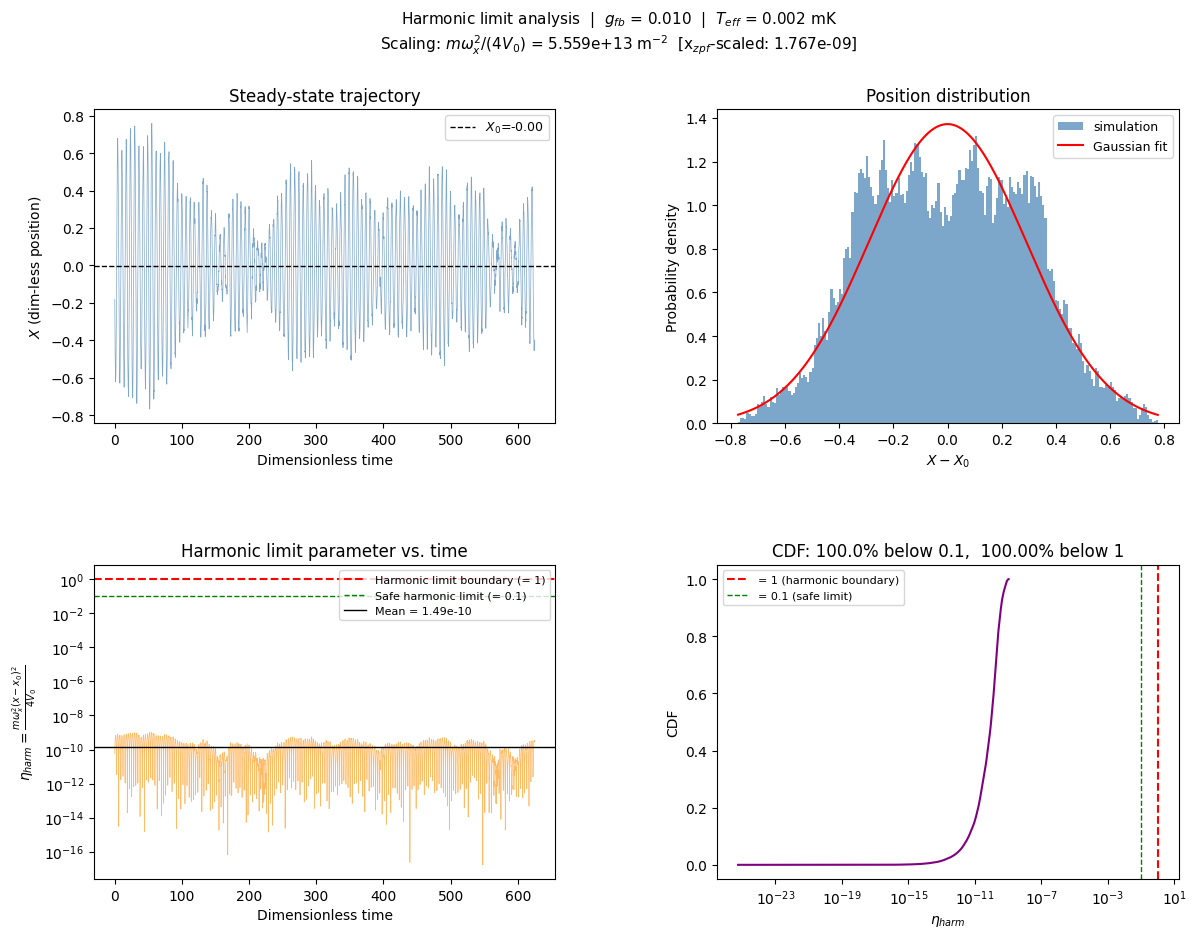

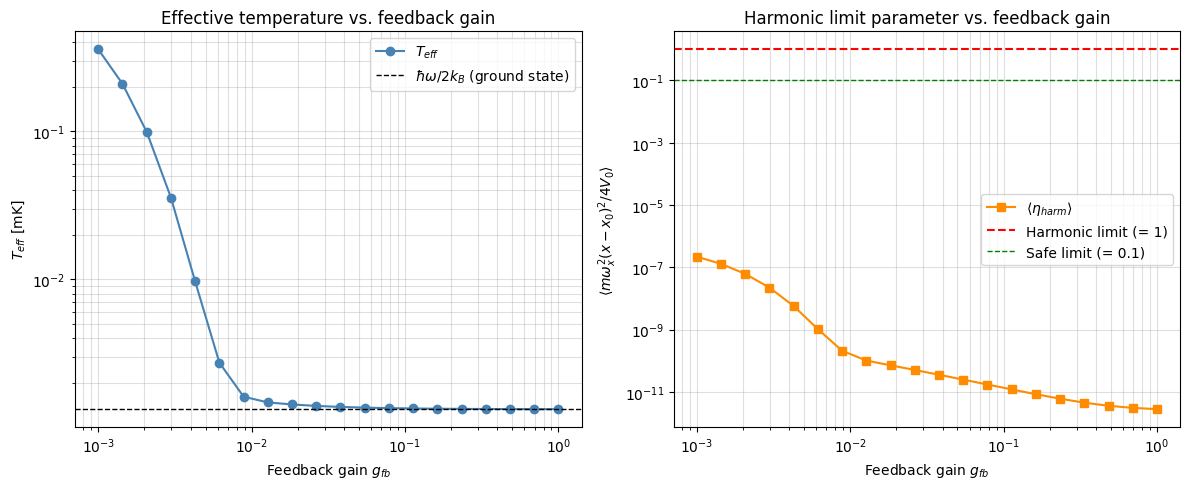

In [1]:
import numpy as np
from scipy.signal import welch
from scipy.integrate import simpson
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from numba import njit

# ============================================================
# Physical parameters
# ============================================================
m = 4.8e-18          # kg (4.8 fg)
f0 = 55e3            # Hz
omega0 = 2 * np.pi * f0   # rad/s  (dimensionless simulation units)
hbar = 6.62607015e-34 / (2 * np.pi)
kB = 1.380649e-23
T0 = hbar * omega0 / kB   # ℏω/kB in Kelvin

print(f"T0       = {T0*1e6:.3f} μK")
print(f"T_ground = {T0/2*1e6:.3f} μK")

# ============================================================
# Trap / beam physical parameters
# ============================================================
wavelength = 1064e-9          # m
P_opt = 500e-3                # W, optical power
w_x = 0.69e-6                 # m, beam waist (x-direction)
omega_x_phys = 2 * np.pi * f0 # rad/s, mechanical frequency

# Nanoparticle geometry
rho = 2000.0                  # kg/m^3, density
d_np = 166e-9                 # m, diameter
r_np = d_np / 2
V_np = (4 / 3) * np.pi * r_np**3
print(f"\nNanoparticle volume V = {V_np:.4e} m^3")

# Real part of polarizability: alpha' = 3*V*eps0*(eps-1)/(eps+2)
eps0 = 8.854187817e-12        # F/m
n_ref = 1.4
eps_r = n_ref**2              # ~ 1.96
alpha_prime = 3 * V_np * eps0 * (eps_r - 1) / (eps_r + 2)
print(f"Polarizability alpha' = {alpha_prime:.4e} C·m^2/V  ({alpha_prime:.4e} F·m^2)")

# Peak intensity of Gaussian beam at focus: I0 = 2P / (pi * w0^2)
I0 = 2 * P_opt / (np.pi * w_x**2)
print(f"Peak intensity I0    = {I0:.4e} W/m^2  (~{I0/1e11:.2f} x 10^11)")

# Trap depth V0 = alpha' * I0 / 4  (from gradient force potential)
V0 = alpha_prime * I0 / 4
print(f"Trap depth V0        = {V0:.4e} J")

# Harmonic limit scaling factor: mw_x^2 / (4*V0)
# If (x - x0)^2 * [mw_x^2/(4V0)] << 1 -> harmonic limit
harm_scale_phys = m * omega_x_phys**2 / (4 * V0)   # units: 1/m^2
print(f"\nHarmonic scale 1/m^2 : {harm_scale_phys:.4e} 1/m^2")
print(f"Equivalent w_0 check : 1/w_x^2 = {1/w_x**2:.4e} 1/m^2  (should match)")
print(f"Ratio harm_scale/1/w_x^2 = {harm_scale_phys / (1/w_x**2):.4f}  (should be ~1 in harmonic approx)")

# x_full: zero-point fluctuation length
x_full = np.sqrt(hbar / (2 * m * omega_x_phys))     # m
print(f"\nx_full = {x_full:.4e} m  =  {x_full/w_x*100:.4f}% of w_x")

# Dimensionless harmonic-limit scale in simulation units
# Simulation uses dimensionless X = x / x_full  ->  x = X * x_full
# Criterion: (X * x_full)^2 * [mw_x^2/(4V0)] << 1
# Equivalent: X^2 * (x_full^2 * mw_x^2 / (4*V0)) << 1
harm_scale_sim = x_full**2 * harm_scale_phys         # dimensionless prefactor
print(f"Harmonic scale (sim units): {harm_scale_sim:.4e}")
print(f"  -> scaled (X-X0)^2 = 1 corresponds to (x-x0) = {1/np.sqrt(harm_scale_phys)*1e9:.1f} nm = {1/np.sqrt(harm_scale_phys)/w_x:.3f} * w_x")

# ============================================================
# Simulation parameters
# ============================================================
eta = 1.0
kappa = 1e-3
n_steps = int(2.5e6)
dt = 0.0005
g_fb = 1 / 100

@njit
def simulate_trajectory(g_fb, dW_all, n_steps, dt, eta, kappa):
    X = 20.0
    P = 20.0
    VX = 0.5
    VP = 0.5
    CXP = 0.0

    K21 = np.sqrt(1 + g_fb**2) - 1
    K22 = np.sqrt(g_fb**2 - 2 + 2 * np.sqrt(1 + g_fb**2))

    X_traj = np.zeros(n_steps)
    VX_traj = np.zeros(n_steps)
    root_term = np.sqrt(8 * eta * kappa)

    for i in range(n_steps):
        dW = dW_all[i]

        X += P * dt + root_term * VX * dW
        P += -X * dt + root_term * CXP * dW
        VX  += (2.0 * CXP - 8.0 * eta * kappa * VX**2) * dt
        VP  += (-2.0 * CXP + 2.0 * kappa - 8.0 * eta * kappa * CXP**2) * dt
        CXP += (VP - VX - 8.0 * eta * kappa * VX * CXP) * dt

        u = -(K21 * X + K22 * P)
        P += u * dt

        X_traj[i] = X
        VX_traj[i] = VX

    return X_traj, VX_traj

# ============================================================
# Run simulation and compute effective temperature
# ============================================================
print("\nRunning simulation...")
np.random.seed(42)
dW_all = np.random.randn(n_steps) * np.sqrt(dt)
half = n_steps // 2

X_traj, VX_traj = simulate_trajectory(g_fb, dW_all, n_steps, dt, eta, kappa)
X_ss = X_traj[half:]
VX_ss = VX_traj[half:]

f, Pxx = welch(X_ss, fs=1.0 / dt, nperseg=len(X_ss) // 4)
mean_X2_traj = simpson(Pxx, x=f)
mean_X2_quantum = mean_X2_traj + np.mean(VX_ss)
T_eff_mK = mean_X2_quantum * T0 * 1e3

x0_sim = np.mean(X_ss)
print(f"<X>      = {x0_sim:.4f}  (equilibrium position in sim units)")
print(f"<X^2>    = {mean_X2_quantum:.4f}")
print(f"T_eff    = {T_eff_mK:.4f} mK")

# ============================================================
# Harmonic limit analysis
# ============================================================
# Convert steady-state trajectory to physical units
x_phys = X_ss * x_full                   # metres
x0_phys = np.mean(x_phys)               # equilibrium (should be ~0)

# The harmonic parameter: eta_harm(t) = m*omega_x^2*(x-x0)^2 / (4*V0)
#   = harm_scale_phys * (x - x0)^2   [in physical units]
#   = harm_scale_sim  * (X - X0)^2   [in simulation units, identical result]
harm_param_phys = harm_scale_phys * (x_phys - x0_phys)**2   # dimensionless
harm_param_sim  = harm_scale_sim  * (X_ss   - x0_sim  )**2   # same, different route

# Sanity: both routes must agree
assert np.allclose(harm_param_phys, harm_param_sim, rtol=1e-6), \
    "Physical and simulation-unit harmonic parameters disagree!"

# Statistics
harm_mean = np.mean(harm_param_phys)
harm_max  = np.max(harm_param_phys)
harm_std  = np.std(harm_param_phys)
print(f"\n--- Harmonic limit diagnostics ---")
print(f"  <eta_harm>   = {harm_mean:.4e}   (want << 1)")
print(f"  max(eta_harm)= {harm_max:.4e}")
print(f"  std(eta_harm)= {harm_std:.4e}")
if harm_mean < 0.01:
    print("  -> DEEP harmonic limit (eta_harm << 0.01)")
elif harm_mean < 0.1:
    print("  -> Good harmonic limit (eta_harm < 0.1)")
elif harm_mean < 0.3:
    print("  -> Marginal harmonic limit (0.1 < eta_harm < 0.3)")
else:
    print("  -> WARNING: NOT in harmonic limit (eta_harm ~ 1 or larger)")

# ============================================================
# Plotting
# ============================================================
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# --- Panel 1: trajectory in sim units ---
ax1 = fig.add_subplot(gs[0, 0])
t_plot = np.arange(len(X_ss)) * dt
thin = max(1, len(t_plot) // 5000)
ax1.plot(t_plot[::thin], X_ss[::thin], lw=0.5, alpha=0.7, color='steelblue')
ax1.axhline(x0_sim, color='k', ls='--', lw=1, label=f'$X_0$={x0_sim:.2f}')
ax1.set_xlabel('Dimensionless time')
ax1.set_ylabel('$X$ (dim-less position)')
ax1.set_title('Steady-state trajectory')
ax1.legend(fontsize=9)

# --- Panel 2: histogram of (X - X0) ---
ax2 = fig.add_subplot(gs[0, 1])
dX = X_ss - x0_sim
ax2.hist(dX, bins=200, density=True, color='steelblue', alpha=0.7, label='simulation')
sigma_X = np.sqrt(mean_X2_quantum - x0_sim**2)  # rough std
x_fit = np.linspace(dX.min(), dX.max(), 500)
gauss_fit = np.exp(-0.5 * (x_fit / np.std(dX))**2) / (np.std(dX) * np.sqrt(2 * np.pi))
ax2.plot(x_fit, gauss_fit, 'r-', lw=1.5, label='Gaussian fit')
ax2.set_xlabel('$X - X_0$')
ax2.set_ylabel('Probability density')
ax2.set_title('Position distribution')
ax2.legend(fontsize=9)

# --- Panel 3: harmonic parameter vs time ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(t_plot[::thin], harm_param_phys[::thin], lw=0.5, alpha=0.6, color='darkorange')
ax3.axhline(1.0,       color='red',   ls='--', lw=1.5, label='Harmonic limit boundary (= 1)')
ax3.axhline(0.1,       color='green', ls='--', lw=1.0, label='Safe harmonic limit (= 0.1)')
ax3.axhline(harm_mean, color='k',     ls='-',  lw=1.0, label=f'Mean = {harm_mean:.2e}')
ax3.set_xlabel('Dimensionless time')
ax3.set_ylabel(r'$\eta_{harm} = \frac{m\omega_x^2(x-x_0)^2}{4V_0}$')
ax3.set_title('Harmonic limit parameter vs. time')
ax3.set_yscale('log')
ax3.legend(fontsize=8)

# --- Panel 4: CDF of harmonic parameter ---
ax4 = fig.add_subplot(gs[1, 1])
sorted_harm = np.sort(harm_param_phys)
cdf = np.linspace(0, 1, len(sorted_harm))
ax4.plot(sorted_harm, cdf, color='purple', lw=1.5)
ax4.axvline(1.0, color='red',   ls='--', lw=1.5, label='= 1 (harmonic boundary)')
ax4.axvline(0.1, color='green', ls='--', lw=1.0, label='= 0.1 (safe limit)')
frac_at_01 = np.mean(harm_param_phys < 0.1)
frac_at_1  = np.mean(harm_param_phys < 1.0)
ax4.set_xlabel(r'$\eta_{harm}$')
ax4.set_ylabel('CDF')
ax4.set_title(f'CDF: {frac_at_01*100:.1f}% below 0.1,  {frac_at_1*100:.2f}% below 1')
ax4.set_xscale('log')
ax4.legend(fontsize=8)

fig.suptitle(
    f'Harmonic limit analysis  |  $g_{{fb}}$ = {g_fb:.3f}  |  '
    f'$T_{{eff}}$ = {T_eff_mK:.3f} mK\n'
    f'Scaling: $m\\omega_x^2/(4V_0)$ = {harm_scale_phys:.3e} m$^{{-2}}$  '
    f'[x$_{{zpf}}$-scaled: {harm_scale_sim:.3e}]',
    fontsize=11
)

plt.show()

gammas = np.logspace(-3, 0, 20)
T_list = []
harm_list = []

for g in gammas:
    X_t, VX_t = simulate_trajectory(g, dW_all, n_steps, dt, eta, kappa)
    Xs = X_t[half:]
    VXs = VX_t[half:]

    f_w, Pxx_w = welch(Xs, fs=1.0 / dt, nperseg=len(Xs) // 4)
    mX2 = simpson(Pxx_w, x=f_w) + np.mean(VXs)
    T_list.append(mX2 * T0 * 1e3)

    x0_g = np.mean(Xs)
    hp = harm_scale_sim * (Xs - x0_g)**2
    harm_list.append(np.mean(hp))

fig2, (axA, axB) = plt.subplots(1, 2, figsize=(12, 5))

T_ground_mK = (T0 / 2) * 1e3
axA.loglog(gammas, T_list, 'o-', color='steelblue', label='$T_{eff}$')
axA.axhline(T_ground_mK, color='k', ls='--', lw=1, label='$\\hbar\\omega/2k_B$ (ground state)')
axA.set_xlabel('Feedback gain $g_{fb}$')
axA.set_ylabel('$T_{eff}$ [mK]')
axA.set_title('Effective temperature vs. feedback gain')
axA.grid(True, which='both', alpha=0.4)
axA.legend()

axB.loglog(gammas, harm_list, 's-', color='darkorange', label=r'$\langle\eta_{harm}\rangle$')
axB.axhline(1.0, color='red',   ls='--', lw=1.5, label='Harmonic limit (= 1)')
axB.axhline(0.1, color='green', ls='--', lw=1.0, label='Safe limit (= 0.1)')
axB.set_xlabel('Feedback gain $g_{fb}$')
axB.set_ylabel(r'$\langle m\omega_x^2(x-x_0)^2 / 4V_0 \rangle$')
axB.set_title('Harmonic limit parameter vs. feedback gain')
axB.grid(True, which='both', alpha=0.4)
axB.legend()

plt.tight_layout()
plt.show()


T0 = 2.640 μK
T_ground = 1.320 μK


/var/folders/pg/vxw1kc2j4msgjcv3j7s6ws940000gn/T/ipykernel_8968/648071820.py:78: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  mean_X2_traj = simps(Pxx, f)


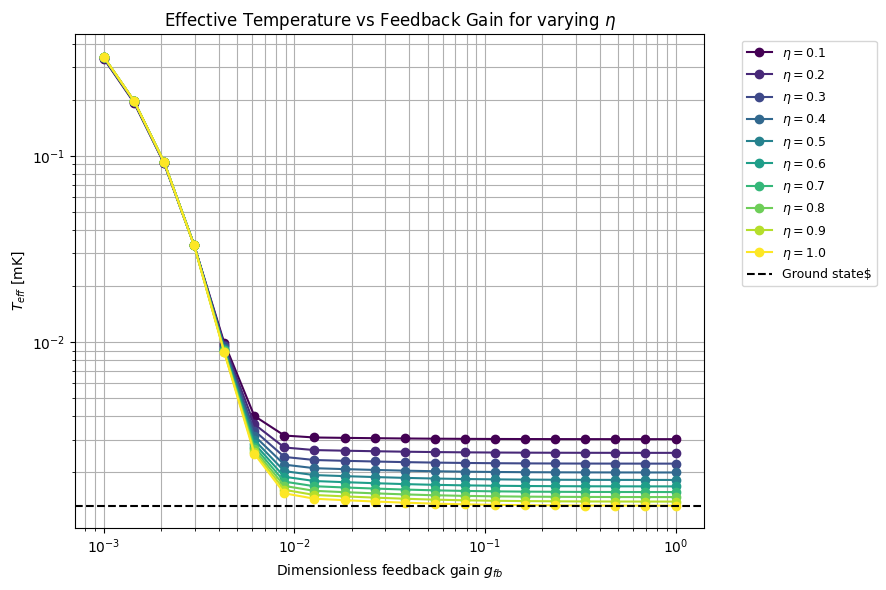

In [4]:
import numpy as np
from scipy.signal import welch
from scipy.integrate import simps
import matplotlib.pyplot as plt
from numba import njit

# Physical parameters
m = 4.8e-18
f0 = 55e3
omega0 = 2*np.pi*f0
hbar = 6.62607015e-34 / (2 * np.pi)
kB = 1.380649e-23
T0 = hbar * omega0 / kB

print(f"T0 = {T0*1e6:.3f} μK")
print(f"T_ground = {T0/2*1e6:.3f} μK")

# Simulation parameters
kappa = 1e-3
window = 20
n_steps = int(2.5e6)
dt = 0.0005

@njit
def simulate_trajectory(g_fb, dW_all, n_steps, dt, eta, kappa, window):
    X = 20.0
    P = 20.0
    VX = 0.5
    VP = 0.5
    CXP = 0.0

    K21 = np.sqrt(1 + g_fb**2) - 1
    K22 = np.sqrt(g_fb**2 - 2 + 2 * np.sqrt(1 + g_fb**2))

    X_traj = np.zeros(n_steps)
    VX_traj = np.zeros(n_steps)
    root_term = np.sqrt(8 * eta * kappa)

    for i in range(n_steps):
        dW = dW_all[i]

        X += P * dt + root_term * VX * dW
        P += -X * dt + root_term * CXP * dW
        VX  += (2.0 * CXP - 8.0 * eta * kappa * VX**2) * dt
        VP  += (-2.0 * CXP + 2.0 * kappa - 8.0 * eta * kappa * CXP**2) * dt
        CXP += (VP - VX - 8.0 * eta * kappa * VX * CXP) * dt

        u = -(K21 * X + K22 * P)
        P += u * dt

        X_traj[i] = X
        VX_traj[i] = VX

    return X_traj, VX_traj


dW_all = np.random.randn(n_steps) * np.sqrt(dt)
half = n_steps // 2

gammas = np.logspace(-3, 0, 20)
etas = np.arange(0.1, 1.1, 0.1)  # 0.1, 0.2, ..., 1.0 (skip 0)

T_ground_mK = (T0 / 2) * 1e3

plt.figure(figsize=(9, 6))
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(etas)))

for eta, color in zip(etas, colors):
    T_list = []
    for g_fb in gammas:
        X_traj, VX_traj = simulate_trajectory(g_fb, dW_all, n_steps, dt, eta, kappa, window)

        X_ss = X_traj[half:]
        VX_ss = VX_traj[half:]

        f, Pxx = welch(X_ss, fs=1.0/dt, nperseg=len(X_ss)//4)
        mean_X2_traj = simps(Pxx, f)
        mean_X2_quantum = mean_X2_traj + np.mean(VX_ss)

        T_mK = mean_X2_quantum * T0 * 1e3
        T_list.append(T_mK)

    plt.loglog(gammas, T_list, 'o-', color=color, label=f'$\\eta={eta:.1f}$')

plt.axhline(T_ground_mK, color='k', linestyle='--', label='Ground state$')
plt.xlabel("Dimensionless feedback gain $g_{fb}$")
plt.ylabel("$T_{eff}$ [mK]")
plt.title("Effective Temperature vs Feedback Gain for varying $\\eta$")
plt.grid(True, which='both')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

T0 = 2.640 μK
T_ground = 1.320 μK


/var/folders/pg/vxw1kc2j4msgjcv3j7s6ws940000gn/T/ipykernel_8968/4119136675.py:78: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  mean_X2_traj = simps(Pxx, f)


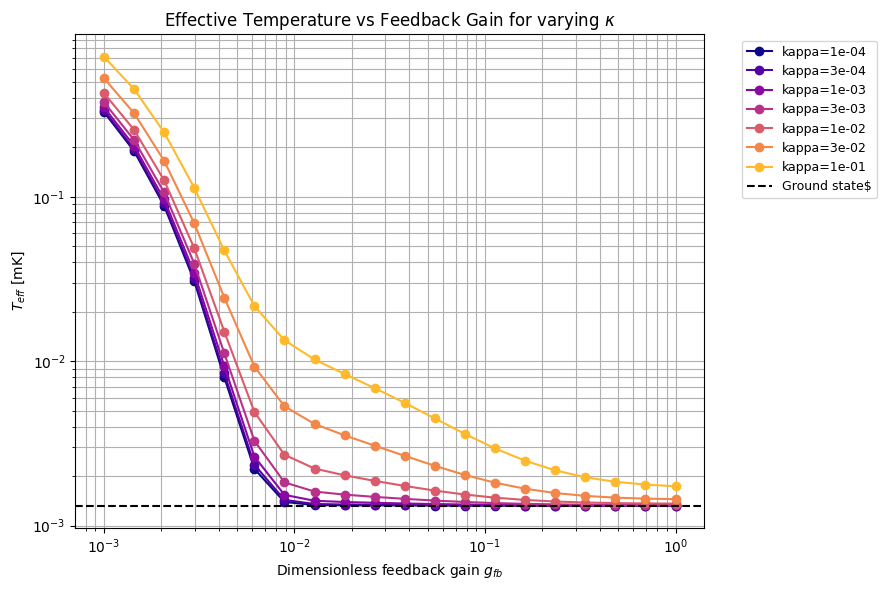

In [7]:
import numpy as np
from scipy.signal import welch
from scipy.integrate import simps
import matplotlib.pyplot as plt
from numba import njit

# Physical parameters
m = 4.8e-18
f0 = 55e3
omega0 = 2*np.pi*f0
hbar = 6.62607015e-34 / (2 * np.pi)
kB = 1.380649e-23
T0 = hbar * omega0 / kB

print(f"T0 = {T0*1e6:.3f} μK")
print(f"T_ground = {T0/2*1e6:.3f} μK")

# Simulation parameters
eta = 1.0
window = 20
n_steps = int(2.5e6)
dt = 0.0005

@njit
def simulate_trajectory(g_fb, dW_all, n_steps, dt, eta, kappa, window):
    X = 20.0
    P = 20.0
    VX = 0.5
    VP = 0.5
    CXP = 0.0

    K21 = np.sqrt(1 + g_fb**2) - 1
    K22 = np.sqrt(g_fb**2 - 2 + 2 * np.sqrt(1 + g_fb**2))

    X_traj = np.zeros(n_steps)
    VX_traj = np.zeros(n_steps)
    root_term = np.sqrt(8 * eta * kappa)

    for i in range(n_steps):
        dW = dW_all[i]

        X += P * dt + root_term * VX * dW
        P += -X * dt + root_term * CXP * dW
        VX  += (2.0 * CXP - 8.0 * eta * kappa * VX**2) * dt
        VP  += (-2.0 * CXP + 2.0 * kappa - 8.0 * eta * kappa * CXP**2) * dt
        CXP += (VP - VX - 8.0 * eta * kappa * VX * CXP) * dt

        u = -(K21 * X + K22 * P)
        P += u * dt

        X_traj[i] = X
        VX_traj[i] = VX

    return X_traj, VX_traj


dW_all = np.random.randn(n_steps) * np.sqrt(dt)
half = n_steps // 2

gammas = np.logspace(-3, 0, 20)
kappas = np.logspace(-4, -1, 7)  # e.g. 1e-4, ~3e-4, 1e-3, ..., 1e-1

T_ground_mK = (T0 / 2) * 1e3

plt.figure(figsize=(9, 6))
cmap = plt.cm.plasma
colors = cmap(np.linspace(0, 0.85, len(kappas)))

for kappa, color in zip(kappas, colors):
    T_list = []
    for g_fb in gammas:
        X_traj, VX_traj = simulate_trajectory(g_fb, dW_all, n_steps, dt, eta, kappa, window)

        X_ss = X_traj[half:]
        VX_ss = VX_traj[half:]

        f, Pxx = welch(X_ss, fs=1.0/dt, nperseg=len(X_ss)//4)
        mean_X2_traj = simps(Pxx, f)
        mean_X2_quantum = mean_X2_traj + np.mean(VX_ss)

        T_mK = mean_X2_quantum * T0 * 1e3
        T_list.append(T_mK)

    plt.loglog(gammas, T_list, 'o-', color=color, label=f'kappa={kappa:.0e}')

plt.axhline(T_ground_mK, color='k', linestyle='--', label='Ground state$')
plt.xlabel("Dimensionless feedback gain $g_{fb}$")
plt.ylabel("$T_{eff}$ [mK]")
plt.title("Effective Temperature vs Feedback Gain for varying $\\kappa$")
plt.grid(True, which='both')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


<Figure size 1400x1000 with 0 Axes>

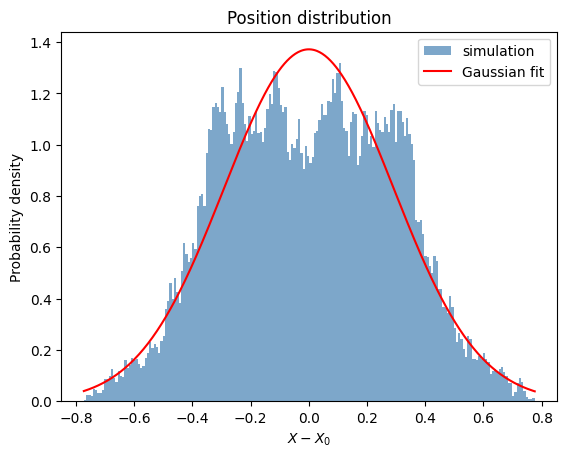

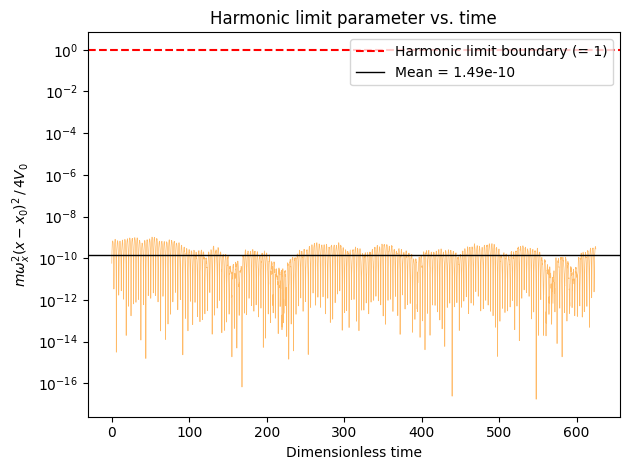

In [14]:
import numpy as np
from scipy.signal import welch
from scipy.integrate import simpson
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from numba import njit

m = 4.8e-18          # kg (4.8 fg)
f0 = 55e3            # Hz
omega0 = 2 * np.pi * f0   # rad/s  (dimensionless simulation units)
hbar = 6.62607015e-34 / (2 * np.pi)
kB = 1.380649e-23
T0 = hbar * omega0 / kB   # ℏω/kB in Kelvin


wavelength = 1064e-9          # m
P_opt = 500e-3                # W, optical power
w_x = 0.69e-6                 # m, beam waist (x-direction)
omega_x_phys = 2 * np.pi * f0 # rad/s, mechanical frequency

# Nanoparticle geometry
rho = 2000.0                  # kg/m^3, density
d_np = 166e-9                 # m, diameter
r_np = d_np / 2
V_np = (4 / 3) * np.pi * r_np**3

#alpha' = 3*V*eps0*(eps-1)/(eps+2)
eps0 = 8.854187817e-12        # F/m
n_ref = 1.4
eps_r = n_ref**2              # ~ 1.96
alpha_prime = 3 * V_np * eps0 * (eps_r - 1) / (eps_r + 2)

# Peak intensity of Gaussian beam at focus: I0 = 2P / (pi * w0^2)
I0 = 2 * P_opt / (np.pi * w_x**2)

# Trap depth V0 = alpha' * I0 / 4  (from gradient force potential)
V0 = alpha_prime * I0 / 4

# Harmonic limit scaling factor: mw_x^2 / (4*V0)
# If (x - x0)^2 * [mw_x^2/(4V0)] << 1 -> harmonic limit
harm_scale_phys = m * omega_x_phys**2 / (4 * V0)   # units: 1/m^2

x_full = np.sqrt(hbar / (2 * m * omega_x_phys))# m

# Dimensionless harmonic-limit scale in simulation units
# Simulation uses dimensionless X = x / x_full  ->  x = X * x_full
# Criterion: (X * x_full)^2 * [mw_x^2/(4V0)] << 1
# Equivalent: X^2 * (x_full^2 * mw_x^2 / (4*V0)) << 1
harm_scale_sim = x_full**2 * harm_scale_phys         # dimensionless prefactor

eta = 1.0
kappa = 1e-3
n_steps = int(2.5e6)
dt = 0.0005
g_fb = 1 / 100

@njit
def simulate_trajectory(g_fb, dW_all, n_steps, dt, eta, kappa):
    X = 20.0
    P = 20.0
    VX = 0.5
    VP = 0.5
    CXP = 0.0

    K21 = np.sqrt(1 + g_fb**2) - 1
    K22 = np.sqrt(g_fb**2 - 2 + 2 * np.sqrt(1 + g_fb**2))

    X_traj = np.zeros(n_steps)
    VX_traj = np.zeros(n_steps)
    root_term = np.sqrt(8 * eta * kappa)

    for i in range(n_steps):
        dW = dW_all[i]

        X += P * dt + root_term * VX * dW
        P += -X * dt + root_term * CXP * dW
        VX  += (2.0 * CXP - 8.0 * eta * kappa * VX**2) * dt
        VP  += (-2.0 * CXP + 2.0 * kappa - 8.0 * eta * kappa * CXP**2) * dt
        CXP += (VP - VX - 8.0 * eta * kappa * VX * CXP) * dt

        u = -(K21 * X + K22 * P)
        P += u * dt

        X_traj[i] = X
        VX_traj[i] = VX

    return X_traj, VX_traj

np.random.seed(42)
dW_all = np.random.randn(n_steps) * np.sqrt(dt)
half = n_steps // 2

X_traj, VX_traj = simulate_trajectory(g_fb, dW_all, n_steps, dt, eta, kappa)
X_ss = X_traj[half:] #maybe worjk without this vs 2
VX_ss = VX_traj[half:]

f, Pxx = welch(X_ss, fs=1.0 / dt, nperseg=len(X_ss) // 4)
mean_X2_traj = simpson(Pxx, x=f)
mean_X2_quantum = mean_X2_traj + np.mean(VX_ss)
T_eff_mK = mean_X2_quantum * T0 * 1e3

x0_sim = np.mean(X_ss)

#harm limit stuff
# Convert steady-state trajectory to physical units
x_phys = X_ss * x_full # metres
x0_phys = np.mean(x_phys)# equilibrium? trap center?

# The harmonic parameter: eta_harm(t) = m*omega_x^2*(x-x0)^2 / (4*V0)
# = harm_scale_phys * (x - x0)^2   [in physical units]
harm_param_phys = harm_scale_phys * (x_phys - x0_phys)**2   # dimensionless

harm_mean = np.mean(harm_param_phys)
harm_max  = np.max(harm_param_phys)
harm_std  = np.std(harm_param_phys)


fig = plt.figure(figsize=(14, 10))

#position histogram to see if guassian
dX = X_ss - x0_sim
x_fit = np.linspace(dX.min(), dX.max(), 500)
gauss_fit = np.exp(-0.5 * (x_fit / np.std(dX))**2) / (np.std(dX) * np.sqrt(2 * np.pi))
 
plt.figure()
plt.hist(dX, bins=200, density=True, color='steelblue', alpha=0.7, label='simulation')
plt.plot(x_fit, gauss_fit, 'r-', lw=1.5, label='Gaussian fit')
plt.xlabel('$X - X_0$')
plt.ylabel('Probability density')
plt.title('Position distribution')
plt.legend()
plt.show()
 
#harmonic parameter vs time
plt.figure()
plt.plot(t_plot[::thin], harm_param_phys[::thin], lw=0.5, alpha=0.6, color='darkorange')
plt.axhline(1.0,       color='red', ls='--', lw=1.5, label='Harmonic limit boundary (= 1)')
plt.axhline(harm_mean, color='k',   ls='-',  lw=1.0, label=f'Mean = {harm_mean:.2e}')
plt.xlabel('Dimensionless time')
plt.ylabel(r'$m\omega_x^2(x-x_0)^2 \, / \, 4V_0$')
plt.title('Harmonic limit parameter vs. time')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()

(x_full / w_0)^2 approx 10^-10... x_full = sqrt(hbar / 2mw_0) so pico meters so x_full / w_0 (micrometers) gives 10^-5 which squared it what we see as men on the plot

Steepness decresases withhigher mass, w_x, and x, and goes up with higher intensity (v_0)

End march 10

<x> looked like a rnaodm walk so now i am trying to see what it looks like for no geedback... because intial condiitons fo <x> and <p> are 10 abut the <x> is going all the way to 175 so there must be something wrong wiht the measuement feedback ..

THIS

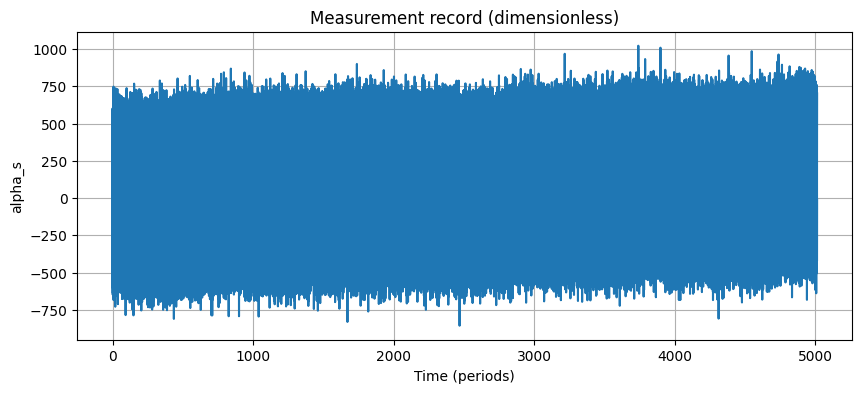

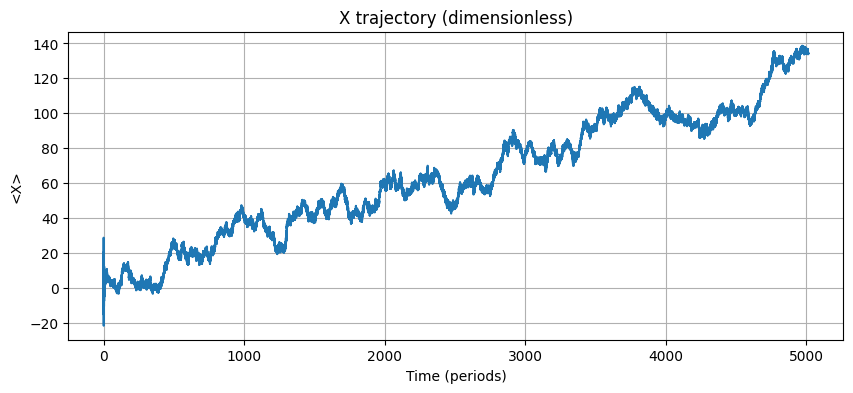

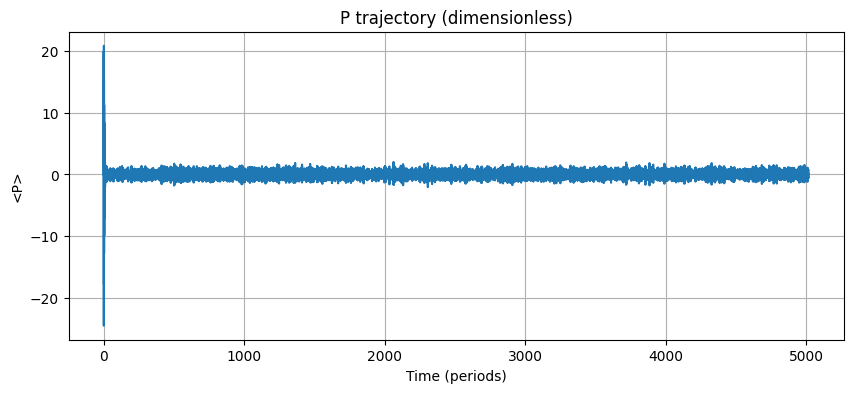

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

hbar = 1.0
m = 1.0
omega0 = 1.0
x0 = np.sqrt(hbar / (m * omega0))
p0 = np.sqrt(hbar * m * omega0)
t0 = 1 / omega0

gamma_sc = 0.01
eta = 1.0
kappa = 1e-2
#Q = omega0 / gammafb
# feedback
# gamma_fb = 1e-2
gamma_fb = 1/100
tau_filter = 10 #time cosntant.. takes x_filter 10 * time = 10 * 1/omega0 about 1.5 oscialltion periods 
#x filter ^ takes 1.5 oscialltion periods to catch up to true position
#too fast and it's too noisy... too slow and it doesn't catch up to true position
#omega_0 = 1, period = 2pi so tau is like about 1.5 oscialltion periods so we're good?
dt_prime = 0.0005
n_steps = int(6.3e7)
window = 50 

@njit
def run_sim(n_steps, dt_prime, gamma_fb, tau_filter, eta, kappa):

    # Initial conditions
    X = 20.0
    P = 20.0
    VX = 1.0
    VP = 1.0
    CXP = 0.0

    # Filter states — OUTSIDE the loop so they accumulate across steps
    x_filtered = 0.0

    root_8ek = np.sqrt(8.0 * eta * kappa)
    sqrt_dt  = np.sqrt(dt_prime)

    # Storage
    X_traj = np.zeros(n_steps)
    P_traj = np.zeros(n_steps)
    VX_traj = np.zeros(n_steps)
    VP_traj = np.zeros(n_steps)
    CXP_traj = np.zeros(n_steps)
    X2_traj = np.zeros(n_steps)
    alpha_s_history = np.zeros(n_steps)
    x_c = 0.0
    x_filtered = 0.0
    for i in range(n_steps - 1):

        dW = np.random.randn() * sqrt_dt

        # how far is current reading from long run average 
        #position update: og position + fraction of gap (fraction set by tau filter)
        #dx_filtered/dt = (alpha_s - x_filtered) / tau_filter 
        #noise has power across all time scales in psd but the rela signal only really spikes at omega 
        #etween the oscillation peak and the noise floor.,,filter 
        #cutoff frequency 1/tau_filter should be just below omega0  slow enough to average out the flat 
        #noise floor but fast enough to still pass the oscillation peak.
        # x_filtered += (alpha_s - x_filtered) * dt_prime / tau_filter

        #velocity-like signal
        #rate of change of the filtered position estimate, scaled by tau_filter.
        #alpha_s is position rn and x_fiteres is position averages overlast tau filter time units (1.5 oscialltion periods)
        # v_estimate = alpha_s - x_filtered
        # use x_c from PREVIOUS timestep in the force
        X += P * dt_prime + root_8ek * VX * dW
        P += -(X - x_c) * dt_prime + root_8ek * CXP * dW #something wierd is happenig here i guess idk 
        VX  += (2.0 * CXP - 8.0 * eta * kappa * VX**2) * dt_prime
        VP  += (-2.0 * CXP + 2.0 * kappa - 8.0 * eta * kappa * CXP**2) * dt_prime
        CXP += (VP - VX - 8.0 * eta * kappa * VX * CXP) * dt_prime

        # now measure and compute x_c for NEXT timestep
        alpha_s = X + dW / (root_8ek * dt_prime)
        alpha_s_history[i+1] = alpha_s #what

        x_filtered_prev = x_filtered
        if i > window:
            x_filtered += (alpha_s_history[i] - x_filtered) * dt_prime / tau_filter
            v_estimate = (x_filtered - x_filtered_prev) / dt_prime
            x_c = x_filtered + gamma_fb * v_estimate  # will be used next iteration

        
        X2 = X**2 + VX

        X_traj[i+1]          = X
        P_traj[i+1]          = P
        VX_traj[i+1]         = VX
        VP_traj[i+1]         = VP
        CXP_traj[i+1]        = CXP
        X2_traj[i+1]         = X2


    return X_traj, P_traj, VX_traj, VP_traj, CXP_traj, X2_traj, alpha_s_history, helpme


out = run_sim(n_steps, dt_prime, gamma_fb, tau_filter, eta, kappa)
X_traj, P_traj, VX_traj, VP_traj, CXP_traj, X2_traj, alpha_s_history, helpme = out

time = np.arange(n_steps) * dt_prime
time_periods = time / (2 * np.pi)

plt.figure(figsize=(10, 4))
plt.plot(time_periods, alpha_s_history)
plt.title("Measurement record (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("alpha_s")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_periods, X_traj)
plt.title("X trajectory (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("<X>")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_periods, P_traj)
plt.title("P trajectory (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("<P>")
plt.grid(True)
plt.show()

THIS OLD

/var/folders/pg/vxw1kc2j4msgjcv3j7s6ws940000gn/T/ipykernel_30104/2898629454.py:67: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  var_x = simps(Pxx, f)


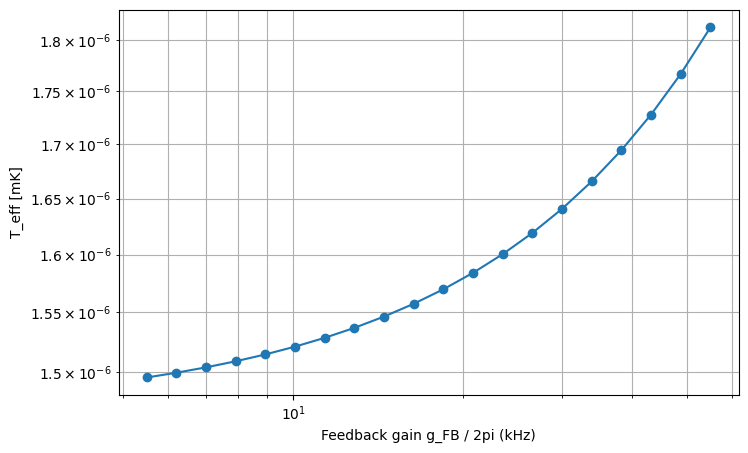

In [18]:
import numpy as np
from scipy.signal import welch 
from scipy.integrate import simps
import matplotlib.pyplot as plt
from numba import njit


eta = 1.0
kappa = 1e-3
window = 20
n_steps = int(2.5e6)
dt = 0.05
omega0 = 55e3# rad / sec x mode
hbar = 6.62607015e-34 / (2* np.pi) #m^2 kg / s
omega_z = omega0
kB = 1.380649e-23
T0 = hbar * (omega0) / kB

@njit
def simulate_trajectory(g_fb, dW_all, n_steps, dt, eta, kappa, tau_filter, window):
    X = 20.0
    P = 20.0
    VX = 1.0
    VP = 1.0
    CXP = 0.0

    X_traj = np.zeros(n_steps)
    root_term = np.sqrt(8.0 * eta * kappa)
    x_c = 0.0
    x_filtered = 0.0

    for i in range(n_steps):
        dW = dW_all[i]

        X += P * dt + root_term * VX * dW
        P += -(X - x_c) * dt + root_term * CXP * dW

        alpha_s = X + dW / (root_term * dt)

        x_filtered_prev = x_filtered
        x_filtered += (alpha_s - x_filtered) * dt / tau_filter
        v_estimate = (x_filtered - x_filtered_prev) / dt

        if i > window:
            x_c = x_filtered + g_fb * v_estimate
        else:
            x_c = 0.0

        VX  += (2.0 * CXP - 8.0 * eta * kappa * VX**2) * dt
        VP  += (-2.0 * CXP + 2.0 * kappa - 8.0 * eta * kappa * CXP**2) * dt
        CXP += (VP - VX - 8.0 * eta * kappa * VX * CXP) * dt

        X_traj[i] = X

    return X_traj


# Simulate multiple feedback gains
gammas = np.logspace(-1, 0, 20)
dW_all = np.random.randn(n_steps) * np.sqrt(dt)
T_list = []
for g_fb in gammas:
    X_traj = simulate_trajectory(g_fb, dW_all, n_steps, dt, eta, kappa, tau_filter, window)
    
    fs = 1.0 / dt
    f, Pxx = welch(X_traj, fs=fs, nperseg=len(X_traj)//4)
    var_x = simps(Pxx, f)
    T_list.append(var_x * T0 / 1e3)
#put in units for plotting
omega_m = 2*np.pi*55e3
gamma_FB = gammas * omega_m
g_pap = gamma_FB / (2*np.pi) / 1e3 #g paper

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,5))
plt.loglog(g_pap, T_list, 'o-')
plt.xlabel("Feedback gain g_FB / 2pi (kHz)")
plt.ylabel("T_eff [mK]")
plt.grid(True, which='both')
plt.show()


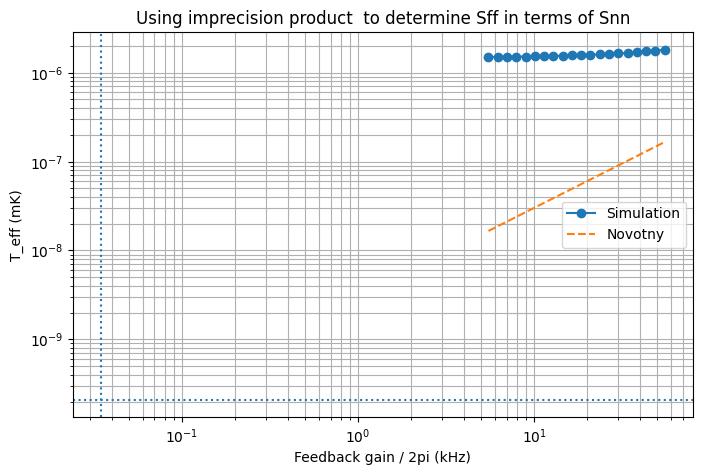

In [19]:
#from paper
# Snn = 1/(8*eta*kappa) #measurement noise (imprecision noise) alpha
#finding Snn using relation between Snn and Sff given imprecision product
# Sff = 8*eta*kappa*np.mean(VX2_list) #fluctuating force (measurement backaction,) from x
# Snn = (1/(Sff * eta))*(hbar/(4*np.pi))**2


Snn = 1 / (8 * eta * kappa) + np.mean(VX2_list) * (8 * eta * kappa +2)
Sff = (1 / (eta)) * (1/((4 * np.pi)**2 * Snn))
#finding Snn using relation between Snn and Sff given imprecision product did not work lol 
T_theory = []
for g_fb in gammas:
    T = np.pi*(Sff/g_fb + g_fb*Snn)*T0 / 1e3
    T_theory.append(T)

T_min = 2*np.pi*np.sqrt(Sff*Snn)*T0 / 1e3
g_opt = np.sqrt(Sff/Snn)

#converting gain of paper to units
omega_m = 2*np.pi*55e3
# g_pap = gammas*omega_m/(2*np.pi)/1e3
g_pap = gammas * omega_m / (2*np.pi) / 1e3




plt.figure(figsize=(8,5))
plt.loglog(g_pap, T_list, 'o-', label='Simulation')
plt.loglog(g_pap, T_theory, '--', label='Novotny')
plt.axhline(T_min, linestyle=':')
plt.axvline(g_opt*omega_m/(2*np.pi)/1e3, linestyle=':')
plt.xlabel("Feedback gain / 2pi (kHz)")
plt.title("Using imprecision product  to determine Sff in terms of Snn")
plt.ylabel("T_eff (mK)")
plt.legend()
plt.grid(True, which='both')
plt.show()

/var/folders/pg/vxw1kc2j4msgjcv3j7s6ws940000gn/T/ipykernel_98735/2711253097.py:85: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  var_X   = simps(Pxx, f)


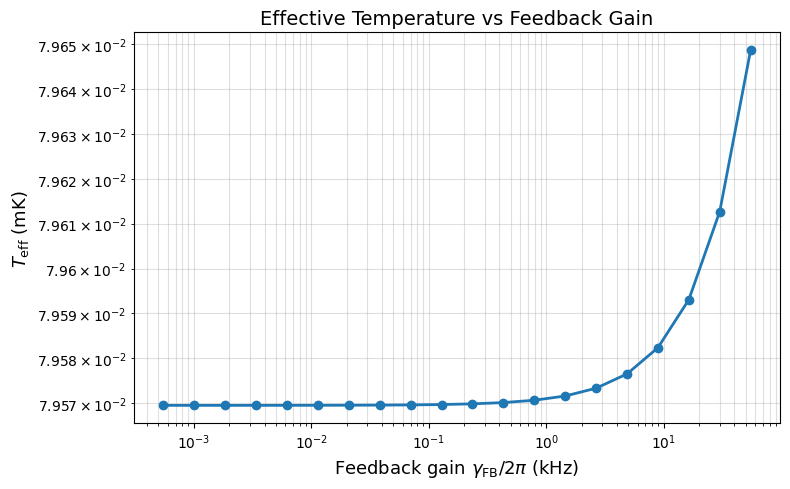

In [27]:
import numpy as np
from scipy.signal import welch
from scipy.integrate import simps
import matplotlib.pyplot as plt
from numba import njit

# ── Physical constants ────────────────────────────────────────────────────────
hbar   = 6.62607015e-34 / (2 * np.pi)
kB     = 1.380649e-23

# ── Parameters ────────────────────────────────────────────────────────────────
eta        = 1.0
kappa      = 1e-3
omega0     = 55e3      
T0         = hbar * omega0 / kB

n_steps    = int(2.5e6)
dt         = 0.005          # dimensionless timestep (units of 1/omega0)
tau_filter = 10.0          # IIR filter time constant (sim units)
window     = 20            # feedback warmup steps

# ── Simulation ────────────────────────────────────────────────────────────────
@njit
def simulate_trajectory(g_fb, dW_all, n_steps, dt, eta, kappa, tau_filter, window):
    X   = 10.0
    P   = 10.0
    VX  = 1.0
    VP  = 1.0
    CXP = 0.0

    x_filtered = 0.0
    root_term  = np.sqrt(8.0 * eta * kappa)

    X_traj  = np.zeros(n_steps)
    VX_traj = np.zeros(n_steps)

    for i in range(n_steps):
        dW = dW_all[i]

        # Measurement
        alpha_s = X + dW / (root_term * dt)

        # IIR filter
        x_filtered_prev = x_filtered
        x_filtered     += (alpha_s - x_filtered) * dt / tau_filter
        v_estimate      = x_filtered - x_filtered_prev

        # Feedback (with warmup)
        if i > window:
            x_c = x_filtered + g_fb * v_estimate
        else:
            x_c = 0.0

        # Equations of motion
        X   +=  P * dt + root_term * VX * dW
        P   += -(X - x_c) * dt + root_term * CXP * dW
        VX  += (2.0 * CXP - 8.0 * eta * kappa * VX**2) * dt
        VP  += (-2.0 * CXP + 2.0 * kappa - 8.0 * eta * kappa * CXP**2) * dt
        CXP += (VP - VX - 8.0 * eta * kappa * VX * CXP) * dt

        X_traj[i]  = X
        VX_traj[i] = VX

    return X_traj, VX_traj


# ── Sweep feedback gain ───────────────────────────────────────────────────────
gammas = np.logspace(-5, 0, 20)
dW_all = np.random.randn(n_steps) * np.sqrt(dt)
T_list = []

for g_fb in gammas:
    X_traj, VX_traj = simulate_trajectory(
        g_fb, dW_all, n_steps, dt, eta, kappa, tau_filter, window
    )

    # Discard transient
    X_ss  = X_traj[n_steps // 2:]
    VX_ss = VX_traj[n_steps // 2:]

    # Variance of conditional mean via Welch
    X_ss_centered = X_ss - np.mean(X_ss)
    fs = 1.0 / dt
    f, Pxx  = welch(X_ss_centered, fs=fs, nperseg=len(X_ss) // 4)
    var_X   = simps(Pxx, f)

    # Total variance = trajectory variance + mean Kalman uncertainty
    var_total = var_X + np.mean(VX_ss)

    # Phonon number and effective temperature
    n_bar = max(var_total - 0.5, 1e-6)
    T_eff = hbar * omega0 / (kB * np.log(1.0 + 1.0 / n_bar))
    T_list.append(T_eff * 1e3)   # mK

# ── Convert gain to physical units for plot ───────────────────────────────────
omega_m  = 2 * np.pi * omega0
gamma_FB = gammas * omega_m
g_pap    = gamma_FB / (2 * np.pi) / 1e3   # kHz

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.loglog(g_pap, T_list, 'o-', linewidth=2, markersize=6)
plt.xlabel(r"Feedback gain $\gamma_{\rm FB} / 2\pi$ (kHz)", fontsize=13)
plt.ylabel(r"$T_{\rm eff}$ (mK)", fontsize=13)
plt.title("Effective Temperature vs Feedback Gain", fontsize=14)
plt.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.show()

/var/folders/pg/vxw1kc2j4msgjcv3j7s6ws940000gn/T/ipykernel_98735/1695255251.py:37: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  var_x = simps(Pxx, f)   # <X^2> in dimensionless units


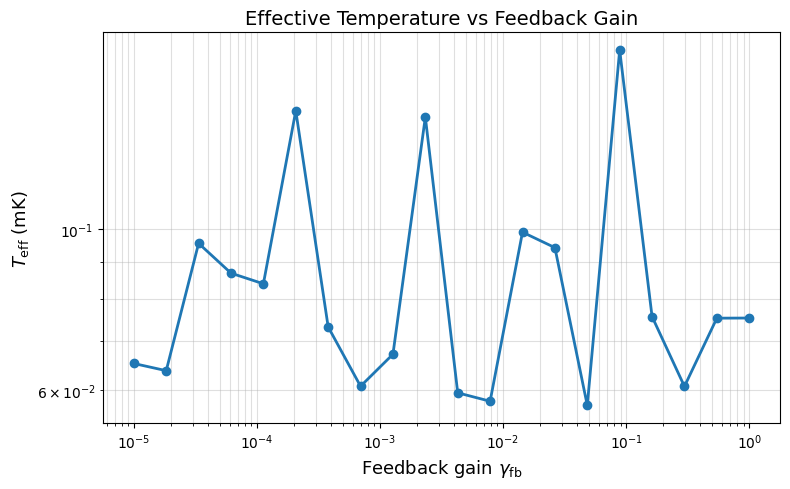

In [20]:
import numpy as np
from scipy.signal import welch
from scipy.integrate import simps
import matplotlib.pyplot as plt
from numba import njit

# ── Physical constants ────────────────────────────────────────────────────────
hbar = 6.62607015e-34 / (2 * np.pi)
kB   = 1.380649e-23

# ── Parameters ────────────────────────────────────────────────────────────────
eta        = 1.0
kappa      = 1e-3
omega0     = 55e3          # rad/s
T0         = hbar * omega0 / kB   # quantum of temperature ~ 4e-7 K for 55 kHz

n_steps    = int(2.5e6)
dt         = 0.005         # dimensionless timestep (units of 1/omega0)
tau_filter = 10.0          # IIR filter time constant (sim units)
window     = 20           # feedback warmup steps


# ── Sweep feedback gain ───────────────────────────────────────────────────────
gammas = np.logspace(-5, 0, 20)
T_list = []

for g_fb in gammas:
    np.random.seed(42)
    helpme = simulate_trajectory(g_fb, n_steps, dt, eta, kappa, tau_filter, window)

    # Discard first half (transient)
    X_ss = helpme[n_steps // 2:]

    # PSD -> variance via Welch
    fs = 1.0 / dt
    f, Pxx = welch(X_ss, fs=fs, nperseg=len(X_ss) // 4)
    var_x = simps(Pxx, f)   # <X^2> in dimensionless units

    # Convert variance to phonon number then to temperature
    # In dimensionless units: <X^2> = n_bar + 0.5  (zero-point = 0.5)
    n_bar = max(var_x - 0.5, 1e-6)   # clamp to avoid log(0)
    T_eff = hbar * omega0 / (kB * np.log(1.0 + 1.0 / n_bar))
    T_eff_mK = T_eff * 1e3
    T_list.append(T_eff_mK)


# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.loglog(gammas, T_list, 'o-', linewidth=2, markersize=6)
plt.xlabel(r"Feedback gain $\gamma_{\rm fb}$", fontsize=13)
plt.ylabel(r"$T_{\rm eff}$ (mK)", fontsize=13)
plt.title("Effective Temperature vs Feedback Gain", fontsize=14)
plt.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.show()

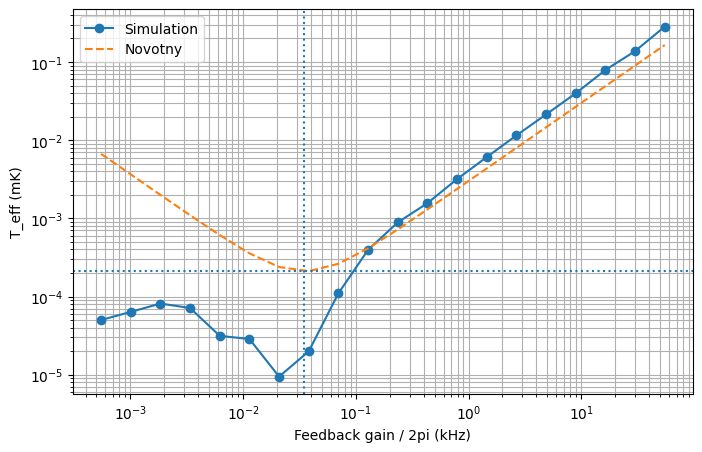

In [48]:
import numpy as np
#from paper
# Snn = dt * VX2

# Snn = 1 / VX2
#vertical shift
Snn = (1/(8*eta*kappa))#measurement noise (imprecision noise) alpha
Sff = (1 / (eta)) * (1/((4 * np.pi)**2 * Snn))
#finding Snn using relation between Snn and Sff given imprecision product did not work lol 
T_theory = []
for g_fb in gammas:
    T = np.pi*(Sff/g_fb + g_fb*Snn)*T0*1e3
    T_theory.append(T)

T_min = 2*np.pi*np.sqrt(Sff*Snn)*T0*1e3
g_opt = np.sqrt(Sff/Snn)

#converting gain of paper to units
omega_m = 2*np.pi*55e3
g_pap = gammas*omega_m/(2*np.pi)/1e3


plt.figure(figsize=(8,5))
plt.loglog(g_pap, T_list, 'o-', label='Simulation')
plt.loglog(g_pap, T_theory, '--', label='Novotny')
plt.axhline(T_min, linestyle=':')
plt.axvline(g_opt*omega_m/(2*np.pi)/1e3, linestyle=':')
plt.xlabel("Feedback gain / 2pi (kHz)")
plt.ylabel("T_eff (mK)")
plt.legend()
plt.grid(True, which='both')
plt.show()

In [57]:
g_opt

0.0006366197723675814

In [49]:
gammas

array([1.00000000e-05, 1.83298071e-05, 3.35981829e-05, 6.15848211e-05,
       1.12883789e-04, 2.06913808e-04, 3.79269019e-04, 6.95192796e-04,
       1.27427499e-03, 2.33572147e-03, 4.28133240e-03, 7.84759970e-03,
       1.43844989e-02, 2.63665090e-02, 4.83293024e-02, 8.85866790e-02,
       1.62377674e-01, 2.97635144e-01, 5.45559478e-01, 1.00000000e+00])

In [50]:
g_pap

array([5.50000000e-04, 1.00813939e-03, 1.84790006e-03, 3.38716516e-03,
       6.20860840e-03, 1.13802594e-02, 2.08597960e-02, 3.82356038e-02,
       7.00851242e-02, 1.28464681e-01, 2.35473282e-01, 4.31617984e-01,
       7.91147439e-01, 1.45015799e+00, 2.65811163e+00, 4.87226735e+00,
       8.93077207e+00, 1.63699329e+01, 3.00057713e+01, 5.50000000e+01])

In [6]:
!pip install scipy


     |████████████████████████████████| 30.3 MB 691 kB/s eta 0:00:01
You should consider upgrading via the '/Users/Roaa/.pyenv/versions/3.9.6/bin/python3.9 -m pip install --upgrade pip' command.


In [3]:
pip install numba

     |████████████████████████████████| 2.7 MB 2.3 MB/s eta 0:00:01
     |████████████████████████████████| 28.8 MB 65.2 MB/s eta 0:00:01
You should consider upgrading via the '/Users/Roaa/.pyenv/versions/3.9.6/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


april 6 2026


x_full = 5.638e-12 m
T0 = 2.640 μK
T_ground = 1.320 μK
(2500000,)


/var/folders/pg/vxw1kc2j4msgjcv3j7s6ws940000gn/T/ipykernel_14271/3524654912.py:92: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  mean_X2_traj = simps(Pxx, f)


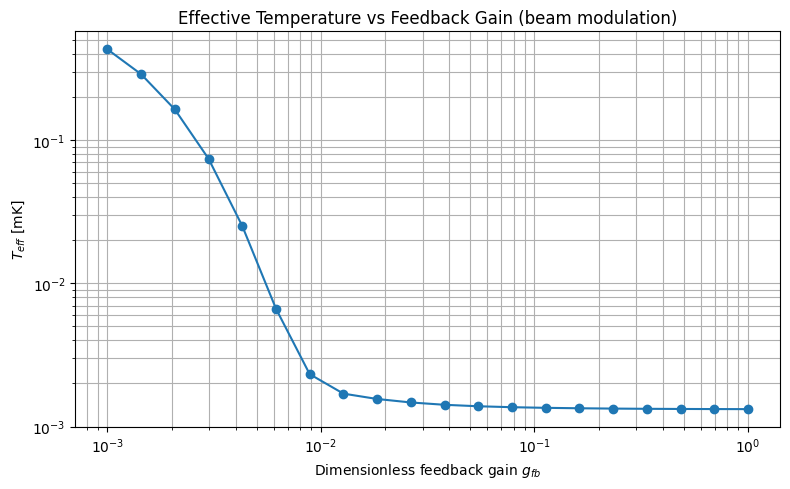

In [11]:
import numpy as np
from scipy.integrate import simps
from scipy.signal import welch
from scipy.integrate import simps
import matplotlib.pyplot as plt
from numba import njit

# Physical parameters
m = 4.8e-18          # kg (4.8 fg)
f0 = 55e3            # Hz
omega0 = 2*np.pi*f0  # rad/s
hbar = 6.62607015e-34 / (2 * np.pi)
kB = 1.380649e-23
x_full = np.sqrt(hbar / (2 * m * omega0))
T0 = hbar * omega0 / kB

print(f"x_full = {x_full:.3e} m")
print(f"T0 = {T0*1e6:.3f} μK")
print(f"T_ground = {T0/2*1e6:.3f} μK")

# Simulation parameters
eta = 1.0
kappa = 1e-3
window = 20
n_steps = int(2.5e6)
dt_prime = 0.0005

@njit
def simulate_trajectory(g_fb, dW_all, n_steps, dt_prime, eta, kappa, window):
    X = 20.0   # ground state initial conditions
    P = 20.0
    VX = 0.5  # ground state variance
    VP = 0.5
    CXP = 0.0

    X_traj = np.zeros(n_steps, dtype=np.float64)
    VX_traj = np.zeros(n_steps, dtype=np.float64)
    # alpha_s_history = np.zeros(n_steps + 1, dtype=np.float64)
    X_est = np.zeros(n_steps + 1, dtype=np.float64)
    root_term = np.sqrt(8.0 * eta * kappa)
    x_c = 0.0

    for i in range(n_steps):
        dW = dW_all[i]

        X += P * dt_prime + root_term * VX * dW

        denom = root_term * dt_prime
        if denom != 0.0:
            alpha_s = X + dW / denom
        else:
            alpha_s = X

        # alpha_s_history[i + 1] = alpha_s
        X_est[i+1] = X

        if i > window:
            adot = (X_est[i] - X_est[i - window]) / (window * dt_prime)
            x_c = -g_fb * adot

        P   += -(X - x_c) * dt_prime + root_term * CXP * dW
        VX  += (2.0 * CXP - 8.0 * eta * kappa * VX**2) * dt_prime
        VP  += (-2.0 * CXP + 2.0 * kappa - 8.0 * eta * kappa * CXP**2) * dt_prime
        CXP += (VP - VX - 8.0 * eta * kappa * VX * CXP) * dt_prime

        X_traj[i] = X
        VX_traj[i] = VX

    return X_traj, VX_traj


# Sanity check at g_fb=0
dW_all = np.random.randn(n_steps) * np.sqrt(dt_prime)
print(dW_all.shape) 
half = n_steps // 2

X_traj, VX_traj = simulate_trajectory(0.0, dW_all, n_steps, dt_prime, eta, kappa, window)
X_ss, VX_ss = X_traj[half:], VX_traj[half:]
X2_base = np.mean(X_ss**2 + VX_ss)

# Simulate multiple feedback gains
gammas = np.logspace(-3, 0, 20)
T_list_beam_2 = []

for g_fb in gammas:
    X_traj, VX_traj = simulate_trajectory(g_fb, dW_all, n_steps, dt_prime, eta, kappa, window)

    X_ss = X_traj[half:]
    VX_ss = VX_traj[half:]

    f, Pxx = welch(X_ss, fs=1.0/dt_prime, nperseg=len(X_ss)//4)
    mean_X2_traj = simps(Pxx, f)
    mean_X2_quantum = mean_X2_traj + np.mean(VX_ss)
    T_mK = mean_X2_quantum * T0 * 1e3
    T_list_beam_2.append(T_mK)

plt.figure(figsize=(8, 5))
plt.loglog(gammas, T_list_beam_2, 'o-')
plt.xlabel("Dimensionless feedback gain $g_{fb}$")
plt.ylabel("$T_{eff}$ [mK]")
plt.title("Effective Temperature vs Feedback Gain (beam modulation)")
plt.grid(True, which='both')
plt.tight_layout()
plt.show()

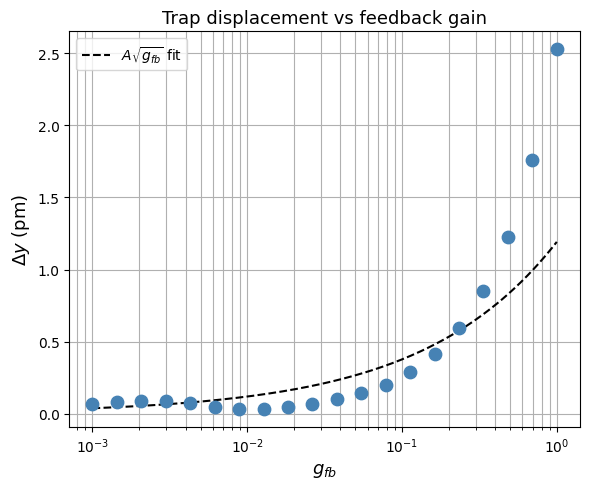

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

# Physical parameters
m = 4.8e-18
f0 = 55e3
omega0 = 2*np.pi*f0
hbar = 6.62607015e-34 / (2*np.pi)
x_zpf = np.sqrt(hbar / (2*m*omega0))

# Sim parameters
eta = 1.0
kappa = 1e-3
n_steps = int(2.5e6)
dt = 0.0005
window = 20

@njit
def simulate_xc(g_fb, dW_all, n_steps, dt, eta, kappa, window):
    X, P = 20.0, 20.0
    VX, VP, CXP = 0.5, 0.5, 0.0
    root_term = np.sqrt(8.0 * eta * kappa)
    X_est = np.zeros(n_steps + 1)
    xc_traj = np.zeros(n_steps)

    for i in range(n_steps):
        dW = dW_all[i]
        X += P * dt + root_term * VX * dW
        X_est[i+1] = X

        x_c = 0.0
        if i > window:
            adot = (X_est[i] - X_est[i - window]) / (window * dt)
            x_c = -g_fb * adot

        P += -(X - x_c) * dt + root_term * CXP * dW
        VX  += (2.0*CXP - 8.0*eta*kappa*VX**2) * dt
        VP  += (-2.0*CXP + 2.0*kappa - 8.0*eta*kappa*CXP**2) * dt
        CXP += (VP - VX - 8.0*eta*kappa*VX*CXP) * dt

        xc_traj[i] = x_c

    return xc_traj

dW_all = np.random.randn(n_steps) * np.sqrt(dt)
half = n_steps // 2

g_fb_vals = np.logspace(-3, 0, 20)
xc_rms_pm = []

for g in g_fb_vals:
    xc = simulate_xc(g, dW_all, n_steps, dt, eta, kappa, window)
    xc_rms = np.sqrt(np.mean(xc[half:]**2)) * x_zpf * 1e12  # pm
    # xc_rms = np.mean(np.abs(xc[half:])) * x_zpf * 1e12  # pm
    xc_rms_pm.append(xc_rms)

xc_rms_pm = np.array(xc_rms_pm)

# sqrt fit
A = np.mean(xc_rms_pm / np.sqrt(g_fb_vals))
g_range = np.logspace(-3, 0, 300)

plt.figure(figsize=(6, 5))
plt.plot(g_range, A * np.sqrt(g_range), 'k--', label=r'$A\sqrt{g_{fb}}$ fit')
plt.scatter(g_fb_vals, xc_rms_pm, s=80, color='steelblue', zorder=5)
plt.xscale('log')
plt.xlabel(r'$g_{fb}$', fontsize=13)
plt.ylabel(r'$\Delta y$ (pm)', fontsize=13)
plt.title('Trap displacement vs feedback gain', fontsize=13)
plt.legend()
plt.grid(True, which='both')
plt.tight_layout()
plt.show()

In [23]:
xc_rms_pm

array([0.06950363, 0.0818647 , 0.08876067, 0.08584594, 0.07116982,
       0.04885898, 0.03171776, 0.03418442, 0.04868584, 0.06950129,
       0.09903755, 0.14130467, 0.20190608, 0.28889248, 0.41385252,
       0.59346028, 0.85172441, 1.22323321, 1.75778437, 2.52706357])